# 08 — Cross-Rate Mean Reversion

**Objective:** Exploit mean-reverting relationships in crypto cross rates (ALT-BTC, ALT-ETH)  
and the triangular-arbitrage basis between actual cross rates and their USD-implied synthetics.

Three distinct strategies:

| # | Strategy | Idea |
|---|----------|------|
| 1 | **Triangular Basis** | Actual ETH-BTC vs implied ETH-USD / BTC-USD — fade the z-score |
| 2 | **BTC-Ratio Bollinger** | Z-score of each ALT/BTC ratio vs its rolling mean — fade extremes |
| 3 | **Cross-Rate Cointegration** | Engle–Granger on pairs of BTC-quoted assets — spread trading |

In [1]:
from _setup import *

import itertools
import duckdb
from statsmodels.tsa.stattools import adfuller, coint
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant
from common.metrics import format_metrics_table

DB_PATH = str(DATA_DIR / "market.duckdb")

START       = "2020-01-01"
END         = "2026-03-12"
DATA_START  = "2019-01-01"
COST_BPS    = 20.0

print(f"DB: {DB_PATH}")
print(f"Period: {START} → {END}")

[setup] Project: trend_crypto  |  DuckDB: /Users/russellfloyd/Dropbox/NRT/nrt_dev/data/market.duckdb
[setup] Ready — np, pd, plt, load_daily_bars, simple_backtest, compute_metrics, ...
DB: /Users/russellfloyd/Dropbox/NRT/nrt_dev/data/market.duckdb
Period: 2020-01-01 → 2026-03-12


## 1 — Load all daily bars (USD + cross rates)

In [2]:
def load_all_daily_bars(db_path: str, start: str, end: str) -> pd.DataFrame:
    """Load daily OHLCV for ALL symbols (USD + cross rates) from candles_1m."""
    con = duckdb.connect(db_path, read_only=True)
    try:
        df = con.execute("""
            SELECT
                symbol,
                time_bucket(INTERVAL '1 day', ts) AS ts,
                FIRST(open ORDER BY ts)  AS open,
                MAX(high)                AS high,
                MIN(low)                 AS low,
                LAST(close ORDER BY ts)  AS close,
                SUM(volume)              AS volume
            FROM candles_1m
            WHERE ts >= ? AND ts <= ?
            GROUP BY symbol, time_bucket(INTERVAL '1 day', ts)
            HAVING open > 0 AND close > 0 AND MAX(high) >= MIN(low)
            ORDER BY ts, symbol
        """, [start, end]).fetch_df()
    finally:
        con.close()
    df["ts"] = pd.to_datetime(df["ts"], utc=True).dt.tz_localize(None)
    df["quote"] = df["symbol"].str.split("-").str[1]
    df["base"]  = df["symbol"].str.split("-").str[0]
    return df

panel = load_all_daily_bars(DB_PATH, DATA_START, END)
print(f"Total rows: {len(panel):,}")
print(f"\nSymbols by quote currency:")
print(panel.groupby("quote")["symbol"].nunique().sort_values(ascending=False).to_string())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Total rows: 909,782

Symbols by quote currency:
quote
USD     366
USDC    366
EUR      34
USDT     27
GBP      25
BTC      24
ETH       5


In [3]:
usd_close = (
    panel.loc[panel["quote"] == "USD"]
    .pivot_table(index="ts", columns="symbol", values="close", aggfunc="first")
)
btc_close = (
    panel.loc[panel["quote"] == "BTC"]
    .pivot_table(index="ts", columns="symbol", values="close", aggfunc="first")
)
eth_close = (
    panel.loc[panel["quote"] == "ETH"]
    .pivot_table(index="ts", columns="symbol", values="close", aggfunc="first")
)

print(f"USD pairs:  {usd_close.shape[1]:>4d} symbols, {usd_close.shape[0]:>5d} days")
print(f"BTC pairs:  {btc_close.shape[1]:>4d} symbols, {btc_close.shape[0]:>5d} days")
print(f"ETH pairs:  {eth_close.shape[1]:>4d} symbols, {eth_close.shape[0]:>5d} days")
print(f"\nBTC-quoted: {sorted(btc_close.columns.tolist())}")
print(f"ETH-quoted: {sorted(eth_close.columns.tolist())}")

USD pairs:   366 symbols,  2628 days
BTC pairs:    24 symbols,  2628 days
ETH pairs:     5 symbols,  2507 days

BTC-quoted: ['AAVE-BTC', 'ADA-BTC', 'ALGO-BTC', 'ATOM-BTC', 'AVAX-BTC', 'BAT-BTC', 'BCH-BTC', 'COMP-BTC', 'CRV-BTC', 'DASH-BTC', 'DOGE-BTC', 'DOT-BTC', 'ETC-BTC', 'ETH-BTC', 'FIL-BTC', 'GRT-BTC', 'ICP-BTC', 'LINK-BTC', 'LTC-BTC', 'SOL-BTC', 'UNI-BTC', 'XLM-BTC', 'XTZ-BTC', 'YFI-BTC']
ETH-quoted: ['ADA-ETH', 'BAT-ETH', 'LINK-ETH', 'LSETH-ETH', 'SOL-ETH']


### Cross-rate data quality — overlap with USD

In [4]:
rows = []
for xr_sym in sorted(btc_close.columns):
    base = xr_sym.split("-")[0]
    usd_sym = f"{base}-USD"
    if usd_sym not in usd_close.columns:
        continue

    xr = btc_close[xr_sym].dropna()
    usd_base = usd_close[usd_sym].dropna()
    btc_usd = usd_close["BTC-USD"].dropna()
    common = xr.index.intersection(usd_base.index).intersection(btc_usd.index)

    if len(common) < 60:
        continue

    actual = xr.loc[common]
    implied = usd_base.loc[common] / btc_usd.loc[common]
    log_basis = np.log(actual) - np.log(implied)

    rows.append({
        "cross_rate": xr_sym,
        "usd_pair": usd_sym,
        "overlap_days": len(common),
        "first": common.min().date(),
        "last": common.max().date(),
        "basis_mean_bps": log_basis.mean() * 1e4,
        "basis_std_bps": log_basis.std() * 1e4,
        "basis_adf_pval": adfuller(log_basis.values, maxlag=21)[1],
    })

basis_df = pd.DataFrame(rows).sort_values("overlap_days", ascending=False)
basis_df.style.format({
    "basis_mean_bps": "{:.1f}",
    "basis_std_bps": "{:.1f}",
    "basis_adf_pval": "{:.4f}",
})

,cross_rate,usd_pair,overlap_days,first,last,basis_mean_bps,basis_std_bps,basis_adf_pval
12,ETH-BTC,ETH-USD,2628,2019-01-01,2026-03-12,-0.1,5.3,0.0000
17,LTC-BTC,LTC-USD,2628,2019-01-01,2026-03-12,-0.4,11.5,0.0000
11,ETC-BTC,ETC-USD,2627,2019-01-01,2026-03-12,-2.2,34.8,0.0000
5,BCH-BTC,BCH-USD,2627,2019-01-01,2026-03-11,-0.1,13.7,0.0000
20,XLM-BTC,XLM-USD,2556,2019-03-14,2026-03-12,-2.7,22.7,0.0000
21,XTZ-BTC,XTZ-USD,2411,2019-08-06,2026-03-12,-1.5,32.5,0.0000
8,DASH-BTC,DASH-USD,2368,2019-09-17,2026-03-12,-1.0,47.0,0.0000
2,ATOM-BTC,ATOM-USD,2250,2020-01-14,2026-03-12,-1.0,37.5,0.0000
6,COMP-BTC,COMP-USD,2081,2020-06-23,2026-03-12,-2.6,41.0,0.0000
16,LINK-BTC,LINK-USD,1921,2020-12-08,2026-03-12,-0.4,14.7,0.0000


---
## 2 — Strategy 1: Triangular Basis Mean Reversion

The **triangular basis** is the log deviation between the actual cross rate  
and the USD-implied synthetic:

$$\text{basis}_t = \log(\text{ALT-BTC}_t) - \log\left(\frac{\text{ALT-USD}_t}{\text{BTC-USD}_t}\right)$$

When this z-score is extreme, we fade it by trading the USD legs.

In [5]:
ZSCORE_LOOKBACK = 63
ENTRY_Z = 2.0
EXIT_Z = 0.5

def compute_tri_basis_signals(
    usd_close: pd.DataFrame,
    btc_close: pd.DataFrame,
    cross_sym: str,
    lookback: int = ZSCORE_LOOKBACK,
) -> pd.DataFrame:
    """Compute triangular basis z-score for a single BTC cross rate."""
    base = cross_sym.split("-")[0]
    usd_sym = f"{base}-USD"

    xr = btc_close[cross_sym]
    base_usd = usd_close[usd_sym]
    btc_usd = usd_close["BTC-USD"]

    common = xr.dropna().index.intersection(base_usd.dropna().index).intersection(btc_usd.dropna().index)
    xr = xr.loc[common]
    implied = base_usd.loc[common] / btc_usd.loc[common]

    basis = np.log(xr) - np.log(implied)
    basis_ma = basis.rolling(lookback, min_periods=lookback // 2).mean()
    basis_std = basis.rolling(lookback, min_periods=lookback // 2).std()
    zscore = (basis - basis_ma) / basis_std.clip(lower=1e-10)

    return pd.DataFrame({
        "basis": basis,
        "zscore": zscore,
        "base_usd": base_usd.loc[common],
        "btc_usd": btc_usd.loc[common],
    }, index=common)


def backtest_tri_basis(
    sig_df: pd.DataFrame,
    base_sym: str,
    entry_z: float = ENTRY_Z,
    exit_z: float = EXIT_Z,
    cost_bps: float = COST_BPS,
    start: str = START,
) -> dict:
    """Backtest a single triangular basis pair.

    When basis z-score > entry_z (actual cross rate is rich vs synthetic),
    short the cross rate = short base-USD, long BTC-USD.
    When basis z-score < -entry_z (actual is cheap), do the opposite.
    """
    df = sig_df.loc[sig_df.index >= start].copy()
    if len(df) < 120:
        return {"label": base_sym, "sharpe": np.nan}

    ret_base = df["base_usd"].pct_change()
    ret_btc  = df["btc_usd"].pct_change()

    position = 0  # +1 = long basis (long base, short BTC), -1 = short basis
    positions = []

    for i in range(len(df)):
        z = df["zscore"].iloc[i]
        if np.isnan(z):
            positions.append(0)
            continue

        if position == 0:
            if z < -entry_z:
                position = 1
            elif z > entry_z:
                position = -1
        elif position == 1:
            if z > -exit_z:
                position = 0
        elif position == -1:
            if z < exit_z:
                position = 0
        positions.append(position)

    pos = pd.Series(positions, index=df.index)
    spread_ret = ret_base - ret_btc
    strategy_ret = pos.shift(1) * spread_ret

    turnover = pos.diff().abs().fillna(0)
    cost = turnover * (cost_bps / 1e4) * 2
    net_ret = strategy_ret - cost
    net_ret = net_ret.fillna(0)

    equity = (1 + net_ret).cumprod()
    m = compute_metrics(equity)
    m["label"] = base_sym
    m["n_trades"] = int(turnover.sum() / 2)
    m["time_in_market"] = float(pos.abs().mean())
    m["equity"] = equity
    return m

print("Triangular basis functions ready.")

Triangular basis functions ready.


In [6]:
eligible_xr = basis_df.loc[
    (basis_df["overlap_days"] >= 500) &
    (basis_df["basis_adf_pval"] < 0.10)
]["cross_rate"].tolist()

print(f"Eligible cross rates for tri-basis (ADF p<0.10, >=500 days): {len(eligible_xr)}")
print(eligible_xr)

tri_results = []
tri_equities = {}

for xr_sym in eligible_xr:
    base = xr_sym.split("-")[0]
    try:
        sig_df = compute_tri_basis_signals(usd_close, btc_close, xr_sym)
        m = backtest_tri_basis(sig_df, base)
        if not np.isnan(m.get("sharpe", np.nan)):
            tri_results.append(m)
            tri_equities[base] = m["equity"]
            print(f"  {base:<8s} SR={m['sharpe']:>6.2f}  CAGR={m['cagr']:>7.1%}  "
                  f"MaxDD={m['max_dd']:>7.1%}  Trades={m['n_trades']:>4d}  "
                  f"TiM={m['time_in_market']:.0%}")
    except Exception as e:
        print(f"  {base}: {e}")

if not tri_results:
    print("\n  No tradeable tri-basis pairs found — relaxing ADF filter...")
    eligible_xr = basis_df.loc[basis_df["overlap_days"] >= 500]["cross_rate"].tolist()
    for xr_sym in eligible_xr:
        base = xr_sym.split("-")[0]
        if base in tri_equities:
            continue
        try:
            sig_df = compute_tri_basis_signals(usd_close, btc_close, xr_sym)
            m = backtest_tri_basis(sig_df, base)
            if not np.isnan(m.get("sharpe", np.nan)):
                tri_results.append(m)
                tri_equities[base] = m["equity"]
                print(f"  {base:<8s} SR={m['sharpe']:>6.2f}  CAGR={m['cagr']:>7.1%}  "
                      f"MaxDD={m['max_dd']:>7.1%}  Trades={m['n_trades']:>4d}")
        except Exception as e:
            print(f"  {base}: {e}")

Eligible cross rates for tri-basis (ADF p<0.10, >=500 days): 23
['ETH-BTC', 'LTC-BTC', 'ETC-BTC', 'BCH-BTC', 'XLM-BTC', 'XTZ-BTC', 'DASH-BTC', 'ATOM-BTC', 'COMP-BTC', 'LINK-BTC', 'UNI-BTC', 'FIL-BTC', 'AAVE-BTC', 'YFI-BTC', 'GRT-BTC', 'ADA-BTC', 'CRV-BTC', 'BAT-BTC', 'DOGE-BTC', 'DOT-BTC', 'SOL-BTC', 'AVAX-BTC', 'ICP-BTC']
  ETH      SR= -1.92  CAGR= -22.3%  MaxDD= -79.1%  Trades= 119  TiM=8%
  LTC      SR= -1.10  CAGR= -17.4%  MaxDD= -70.0%  Trades= 129  TiM=8%
  ETC      SR= -0.51  CAGR= -10.2%  MaxDD= -51.7%  Trades=  99  TiM=6%
  BCH      SR= -1.45  CAGR= -28.7%  MaxDD= -87.8%  Trades= 112  TiM=7%
  XLM      SR= -1.52  CAGR= -23.4%  MaxDD= -81.0%  Trades= 100  TiM=6%
  XTZ      SR= -0.02  CAGR=  -5.3%  MaxDD= -59.6%  Trades= 107  TiM=7%
  DASH     SR= -1.30  CAGR= -29.3%  MaxDD= -89.8%  Trades= 115  TiM=7%
  ATOM     SR= -0.99  CAGR= -22.6%  MaxDD= -80.5%  Trades= 100  TiM=6%
  COMP     SR= -0.82  CAGR= -24.5%  MaxDD= -81.4%  Trades= 103  TiM=8%
  LINK     SR= -1.11  CAGR= -20.3%  

  DOGE     SR= -0.32  CAGR=  -5.5%  MaxDD= -35.4%  Trades=  61  TiM=5%


  DOT      SR= -0.15  CAGR=  -3.4%  MaxDD= -32.6%  Trades=  77  TiM=6%
  SOL      SR= -1.37  CAGR= -24.1%  MaxDD= -73.4%  Trades=  80  TiM=6%
  AVAX     SR= -0.59  CAGR= -15.1%  MaxDD= -51.7%  Trades=  77  TiM=8%
  ICP      SR= -1.10  CAGR= -29.5%  MaxDD= -80.2%  Trades=  69  TiM=8%


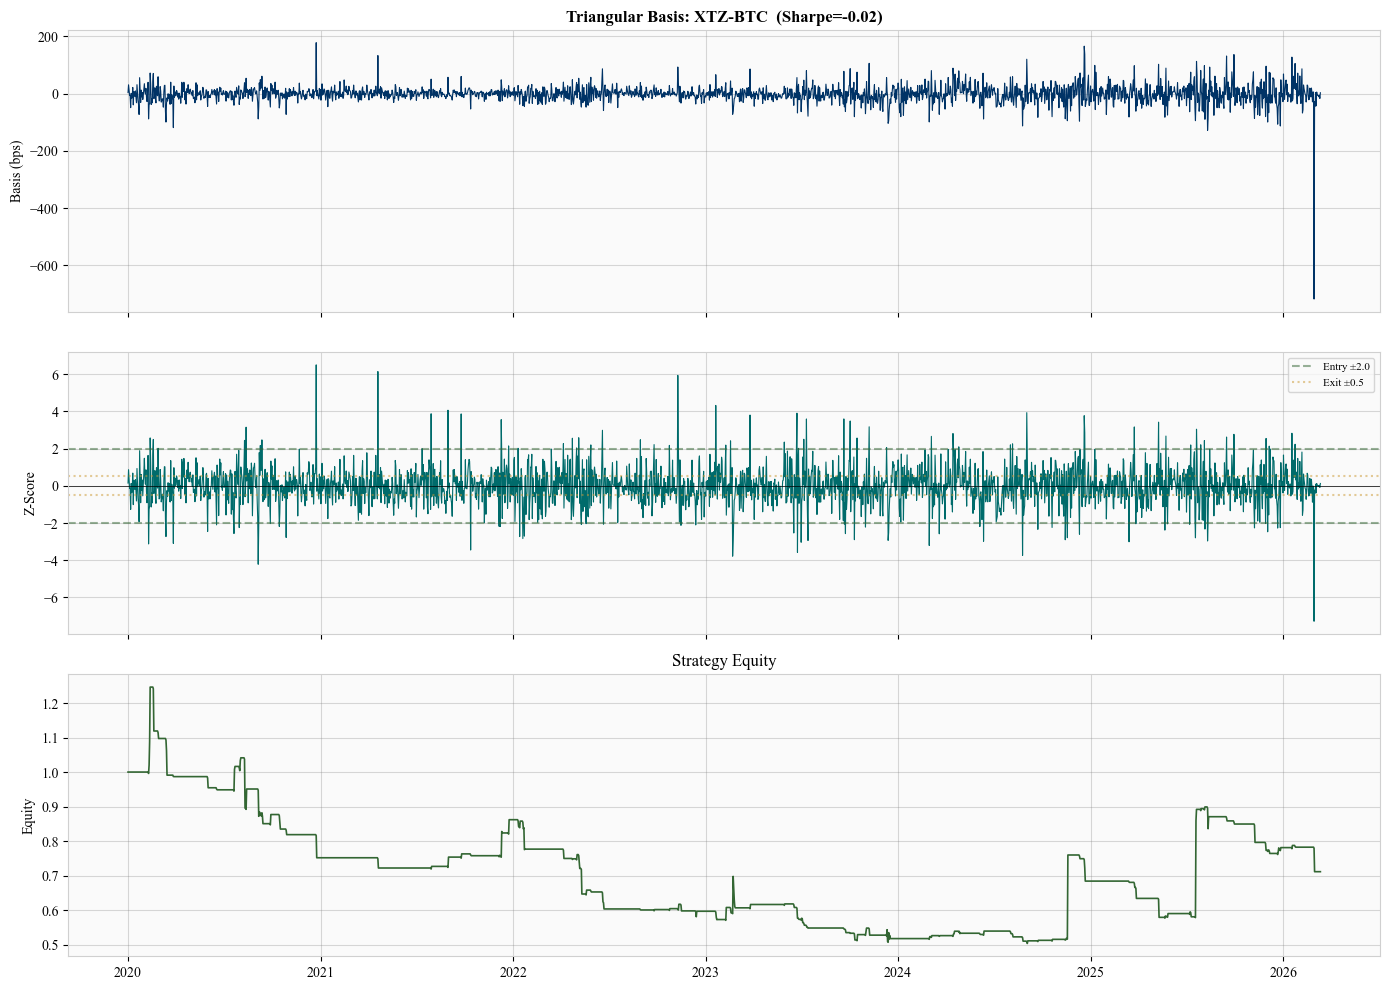

In [7]:
if tri_results:
    tri_sorted = sorted(tri_results, key=lambda x: x.get("sharpe", -99), reverse=True)
    best = tri_sorted[0]

    sig_df = compute_tri_basis_signals(
        usd_close, btc_close, f"{best['label']}-BTC"
    )
    plot_df = sig_df.loc[sig_df.index >= START]

    fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

    axes[0].plot(plot_df.index, plot_df["basis"] * 1e4, color=NAVY, lw=0.8)
    axes[0].set_ylabel("Basis (bps)")
    axes[0].set_title(
        f"Triangular Basis: {best['label']}-BTC  (Sharpe={best['sharpe']:.2f})",
        fontweight="bold", fontsize=12,
    )

    axes[1].plot(plot_df.index, plot_df["zscore"], color=TEAL, lw=0.8)
    axes[1].axhline(ENTRY_Z, color=GREEN, ls="--", alpha=0.5, label=f"Entry ±{ENTRY_Z}")
    axes[1].axhline(-ENTRY_Z, color=GREEN, ls="--", alpha=0.5)
    axes[1].axhline(EXIT_Z, color=GOLD, ls=":", alpha=0.5, label=f"Exit ±{EXIT_Z}")
    axes[1].axhline(-EXIT_Z, color=GOLD, ls=":", alpha=0.5)
    axes[1].axhline(0, color="black", lw=0.5)
    axes[1].set_ylabel("Z-Score")
    axes[1].legend(fontsize=8)

    eq = best["equity"]
    axes[2].plot(eq.index, eq.values, color=GREEN, lw=1.2)
    axes[2].set_ylabel("Equity")
    axes[2].set_title("Strategy Equity")

    fig.tight_layout()
    plt.show()
else:
    print("No tri-basis results to plot.")

### Tri-basis portfolio (equal-weight)

In [8]:
if len(tri_equities) >= 2:
    rets = pd.DataFrame({k: v.pct_change() for k, v in tri_equities.items()}).fillna(0)
    port_ret = rets.mean(axis=1)
    tri_port_eq = (1 + port_ret).cumprod()
    tri_port_m = compute_metrics(tri_port_eq)
    tri_port_m["label"] = "Tri-Basis Portfolio"
    print(format_metrics_table([tri_port_m]))
    print(f"\nN pairs: {len(tri_equities)}")
else:
    tri_port_eq = pd.Series(dtype=float)
    print("Not enough pairs for a portfolio.")

Strategy                           CAGR      Vol   Sharpe  Sortino    MaxDD    Hit%    Skew    Kurt
---------------------------------------------------------------------------------------------------
Tri-Basis Portfolio             -17.3%    5.1%    -3.68    -3.94  -69.6%  24.5%   -1.64   32.69

N pairs: 23


---
## 3 — Strategy 2: BTC-Ratio Bollinger Mean Reversion

Each ALT-BTC cross rate represents the relative value of that alt vs BTC.  
Compute a rolling z-score of each log ratio. When z-score is extreme,  
fade the move — expressing the trade as long/short USD legs.

This is a **cross-sectional** strategy: at each rebalance, go long the  
cheapest (most negative z-score) alts and short the richest.

In [9]:
RATIO_LOOKBACK = 63
TOP_N = 3

btc_usd = usd_close["BTC-USD"]

btc_bases = sorted(set(
    sym.split("-")[0] for sym in btc_close.columns
    if f"{sym.split('-')[0]}-USD" in usd_close.columns
))
print(f"BTC-quoted alts with USD pairs: {len(btc_bases)}")
print(btc_bases)

BTC-quoted alts with USD pairs: 24
['AAVE', 'ADA', 'ALGO', 'ATOM', 'AVAX', 'BAT', 'BCH', 'COMP', 'CRV', 'DASH', 'DOGE', 'DOT', 'ETC', 'ETH', 'FIL', 'GRT', 'ICP', 'LINK', 'LTC', 'SOL', 'UNI', 'XLM', 'XTZ', 'YFI']


In [10]:
log_ratios = pd.DataFrame(index=btc_close.index)
for base in btc_bases:
    xr = btc_close.get(f"{base}-BTC")
    if xr is None:
        continue
    log_ratios[base] = np.log(xr)

ratio_ma = log_ratios.rolling(RATIO_LOOKBACK, min_periods=RATIO_LOOKBACK // 2).mean()
ratio_std = log_ratios.rolling(RATIO_LOOKBACK, min_periods=RATIO_LOOKBACK // 2).std()
ratio_zscore = (log_ratios - ratio_ma) / ratio_std.clip(lower=1e-10)

ratio_zscore = ratio_zscore.loc[ratio_zscore.index >= START]
print(f"Z-score panel: {ratio_zscore.shape[0]} days × {ratio_zscore.shape[1]} alts")
ratio_zscore.tail()

Z-score panel: 2263 days × 24 alts


,AAVE,ADA,ALGO,ATOM,AVAX,BAT,BCH,COMP,CRV,DASH,...,FIL,GRT,ICP,LINK,LTC,SOL,UNI,XLM,XTZ,YFI
ts,,,,,,,,,,,,,,,,,,,,,
2026-03-08,-1.630637,-1.449416,NaN,-0.655653,-0.388404,-1.767254,-0.525458,-0.806462,-1.009123,-0.994264,...,-0.395996,-1.623418,NaN,-0.589452,-0.054052,-0.909826,0.311010,-1.264467,-1.704865,-0.888078
2026-03-09,-2.012567,-1.583256,NaN,-0.989355,-0.215247,-1.904947,-0.887690,-1.652710,-0.954165,-0.916390,...,-0.953549,-1.558497,NaN,-0.502905,-0.392328,-0.837597,0.682537,-1.865023,-2.046960,-0.968957
2026-03-10,-1.485004,-1.502256,NaN,-0.926787,0.072805,-2.032591,-1.032193,-1.514968,-1.149838,-0.988006,...,-2.462279,-1.940270,NaN,-0.628854,-0.831983,-0.941001,0.369975,-1.022157,-2.262119,-1.623638
2026-03-11,-1.618962,-1.527143,NaN,-0.648380,0.037825,-1.862896,-0.922656,-0.315734,-1.580528,-0.971401,...,-2.123894,-1.857278,NaN,-0.661046,-0.494034,-0.864953,0.477450,-1.007065,-2.138621,-1.259218
2026-03-12,-1.793182,-1.481794,NaN,-0.603431,0.298388,-1.753368,NaN,-0.771733,-1.442789,-0.983937,...,-2.156984,NaN,NaN,-0.623042,-0.583862,-0.871445,NaN,-1.115409,-1.985943,NaN


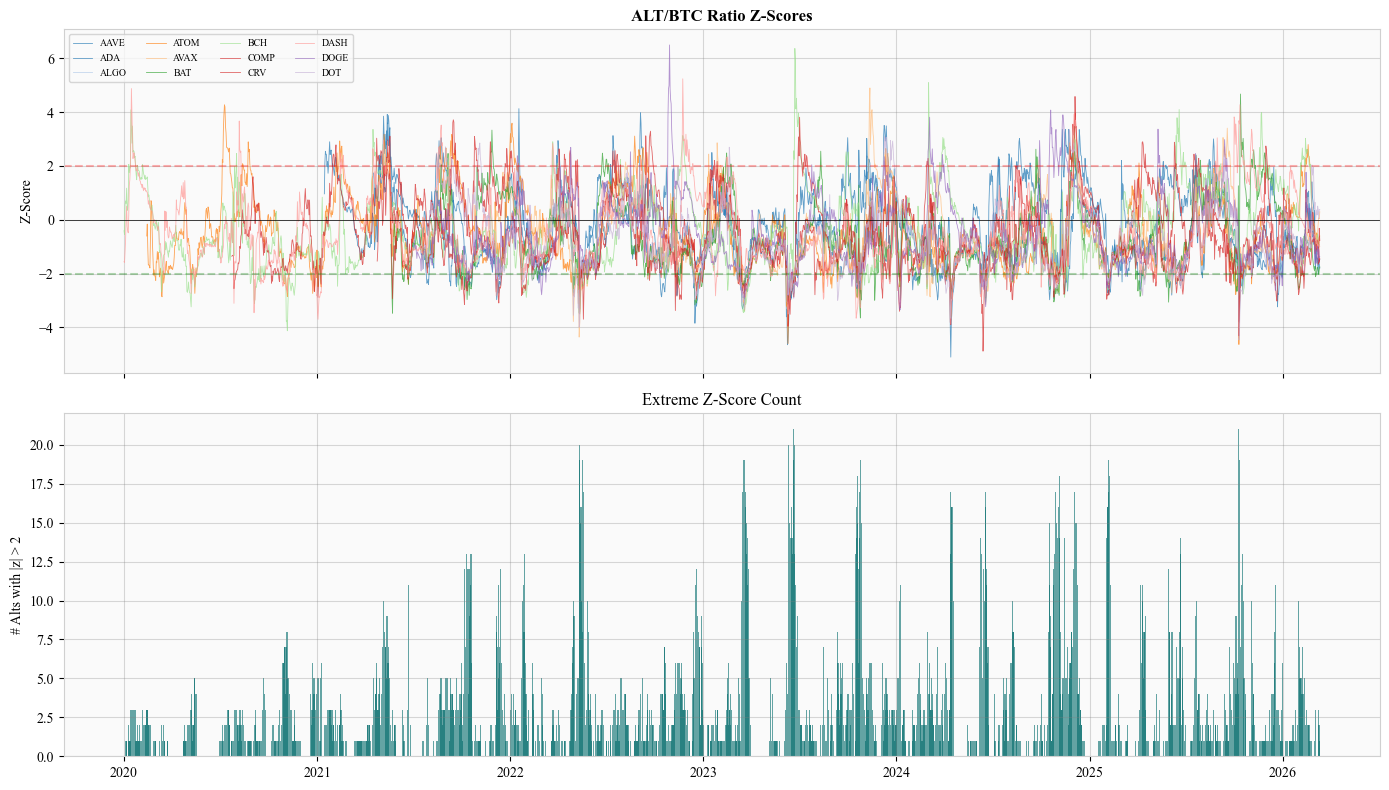

In [11]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

colors_cycle = plt.cm.tab20(np.linspace(0, 1, len(btc_bases)))
for i, base in enumerate(btc_bases[:12]):
    if base in ratio_zscore.columns:
        axes[0].plot(ratio_zscore.index, ratio_zscore[base], lw=0.6,
                     alpha=0.7, label=base, color=colors_cycle[i])
axes[0].axhline(2, color="red", ls="--", alpha=0.3)
axes[0].axhline(-2, color="green", ls="--", alpha=0.3)
axes[0].axhline(0, color="black", lw=0.5)
axes[0].set_ylabel("Z-Score")
axes[0].set_title("ALT/BTC Ratio Z-Scores", fontweight="bold")
axes[0].legend(fontsize=7, ncol=4, loc="upper left")

n_extreme = (ratio_zscore.abs() > 2).sum(axis=1)
axes[1].bar(n_extreme.index, n_extreme.values, width=1.5, color=TEAL, alpha=0.6)
axes[1].set_ylabel("# Alts with |z| > 2")
axes[1].set_title("Extreme Z-Score Count")

fig.tight_layout()
plt.show()

In [12]:
usd_ret = usd_close.pct_change()
btc_ret = usd_ret["BTC-USD"]

def build_ratio_mr_weights(
    zscore: pd.DataFrame,
    top_n: int = TOP_N,
) -> pd.DataFrame:
    """Long-short weights from BTC-ratio z-scores.

    Long the top_n most negative z-scores (cheap vs BTC),
    short the top_n most positive (rich vs BTC).
    Hedge with BTC so the portfolio is BTC-beta neutral.
    """
    weights = pd.DataFrame(0.0, index=zscore.index, columns=[])

    for ts in zscore.index:
        row = zscore.loc[ts].dropna()
        if len(row) < 2 * top_n:
            continue

        cheapest = row.nsmallest(top_n).index.tolist()
        richest  = row.nlargest(top_n).index.tolist()

        w = 1.0 / (2 * top_n)
        for base in cheapest:
            sym = f"{base}-USD"
            if sym not in weights.columns:
                weights[sym] = 0.0
            weights.loc[ts, sym] = w

        for base in richest:
            sym = f"{base}-USD"
            if sym not in weights.columns:
                weights[sym] = 0.0
            weights.loc[ts, sym] = -w

        if "BTC-USD" not in weights.columns:
            weights["BTC-USD"] = 0.0
        net_alt = weights.loc[ts].drop("BTC-USD", errors="ignore").sum()
        weights.loc[ts, "BTC-USD"] = -net_alt

    return weights.fillna(0.0)

ratio_weights = build_ratio_mr_weights(ratio_zscore, top_n=TOP_N)

common_syms = ratio_weights.columns.intersection(usd_ret.columns)
ratio_bt = simple_backtest(
    ratio_weights[common_syms],
    usd_ret[common_syms],
    cost_bps=COST_BPS,
)

ratio_eq = ratio_bt.set_index("ts")["portfolio_equity"]
ratio_m = compute_metrics(ratio_eq)
ratio_m["label"] = f"BTC-Ratio MR (top {TOP_N})"
ratio_m["avg_turnover"] = float(ratio_bt["turnover"].mean())

print(format_metrics_table([ratio_m]))
print(f"\nAvg daily turnover: {ratio_m['avg_turnover']:.1%}")
print(f"Avg gross exposure: {ratio_bt['gross_exposure'].mean():.1%}")

/var/folders/_n/5w8bl1bx1mv_wyxmz1qm5blr0000gn/T/ipykernel_80156/2215438876.py:1: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  usd_ret = usd_close.pct_change()


Strategy                           CAGR      Vol   Sharpe  Sortino    MaxDD    Hit%    Skew    Kurt
---------------------------------------------------------------------------------------------------
BTC-Ratio MR (top 3)            -49.0%   34.8%    -1.76    -2.15  -98.6%  48.5%   -0.55    6.50

Avg daily turnover: 38.8%
Avg gross exposure: 100.0%


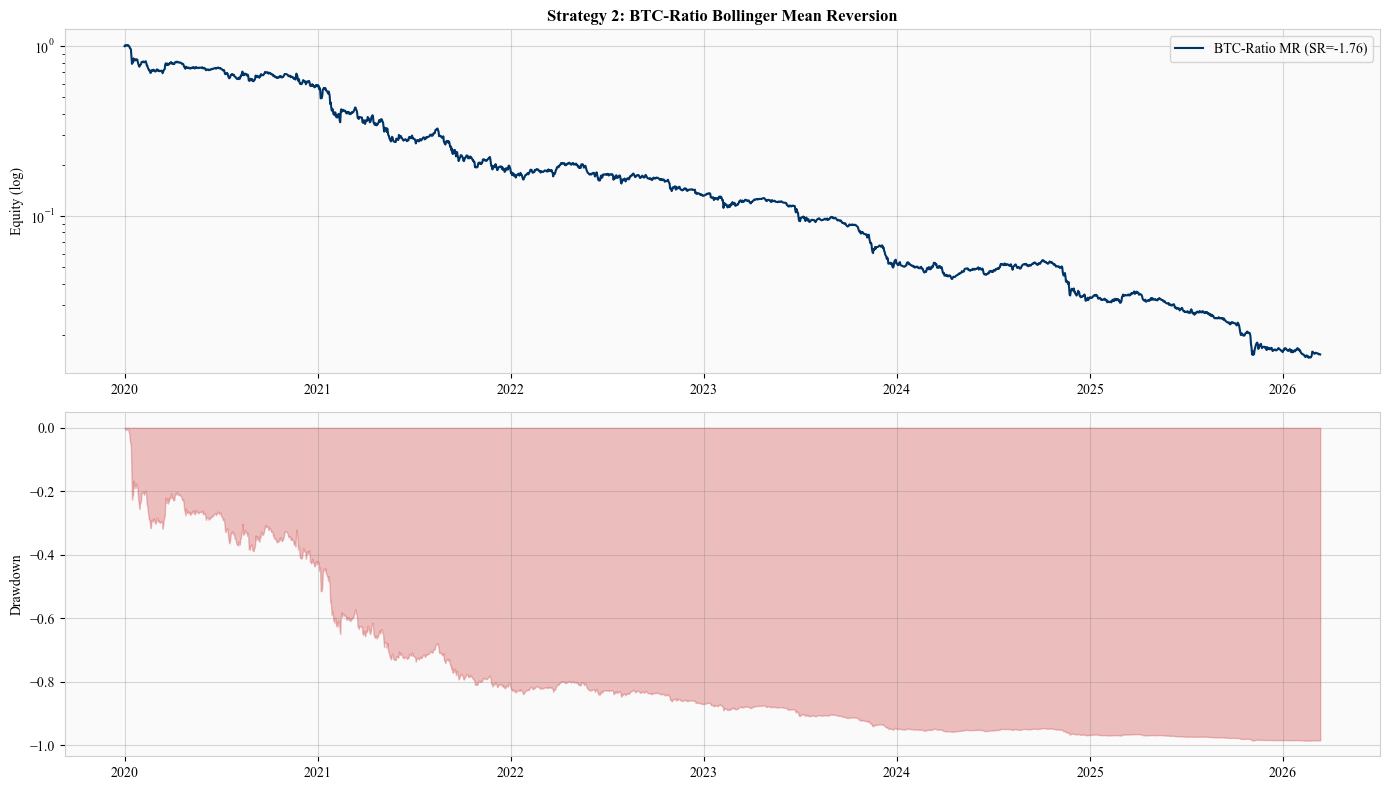

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(ratio_eq.index, ratio_eq.values, color=NAVY, lw=1.5,
             label=f"BTC-Ratio MR (SR={ratio_m['sharpe']:.2f})")
axes[0].set_yscale("log")
axes[0].set_ylabel("Equity (log)")
axes[0].set_title("Strategy 2: BTC-Ratio Bollinger Mean Reversion", fontweight="bold")
axes[0].legend()

dd = ratio_eq / ratio_eq.cummax() - 1
axes[1].fill_between(dd.index, 0, dd.values, color=RED, alpha=0.3)
axes[1].set_ylabel("Drawdown")

fig.tight_layout()
plt.show()

### Parameter sensitivity — lookback and top-N

In [14]:
sweep_results = []
for lb in [21, 42, 63, 126]:
    z = (log_ratios.loc[log_ratios.index >= START] -
         log_ratios.rolling(lb, min_periods=lb // 2).mean().loc[log_ratios.index >= START]) / \
        log_ratios.rolling(lb, min_periods=lb // 2).std().clip(lower=1e-10).loc[log_ratios.index >= START]

    for tn in [2, 3, 5]:
        w = build_ratio_mr_weights(z, top_n=tn)
        cs = w.columns.intersection(usd_ret.columns)
        if len(cs) == 0:
            continue
        bt = simple_backtest(w[cs], usd_ret[cs], cost_bps=COST_BPS)
        if bt.empty:
            continue
        eq = bt.set_index("ts")["portfolio_equity"]
        m = compute_metrics(eq)
        m["lookback"] = lb
        m["top_n"] = tn
        m["avg_turnover"] = float(bt["turnover"].mean())
        sweep_results.append(m)

sweep_df = pd.DataFrame(sweep_results)
pivot = sweep_df.pivot_table(index="lookback", columns="top_n", values="sharpe")
print("Sharpe Ratio — lookback × top_n:")
print(pivot.to_string(float_format="{:.2f}".format))
print()
pivot_cagr = sweep_df.pivot_table(index="lookback", columns="top_n", values="cagr")
print("CAGR — lookback × top_n:")
print(pivot_cagr.to_string(float_format="{:.1%}".format))

Sharpe Ratio — lookback × top_n:
top_n        2     3     5
lookback                  
21       -2.11 -2.20 -2.02
42       -1.89 -1.68 -1.45
63       -1.33 -1.76 -1.23
126      -0.96 -0.81 -0.41

CAGR — lookback × top_n:
top_n         2      3      5
lookback                     
21       -64.6% -56.4% -40.1%
42       -61.2% -47.5% -31.5%
63       -48.5% -49.0% -28.1%
126      -38.6% -28.4% -11.3%


---
## 4 — Strategy 3: Cross-Rate Cointegration Pairs

Test all pairs of BTC-quoted cross rates for cointegration.  
This extends the existing Jansen pairs-trading framework to cross rates,  
looking for mean-reverting spreads between e.g. SOL-BTC and ETH-BTC.

In [15]:
min_obs = 365
btc_log = np.log(btc_close).dropna(how="all")

valid_syms = [c for c in btc_log.columns if btc_log[c].dropna().shape[0] >= min_obs]
print(f"BTC-quoted symbols with >= {min_obs} days: {len(valid_syms)}")

pairs = list(itertools.combinations(valid_syms, 2))
print(f"Pairs to test: {len(pairs)}")

coint_results = []
for s1, s2 in pairs:
    p1 = btc_log[s1].dropna()
    p2 = btc_log[s2].dropna()
    common = p1.index.intersection(p2.index)
    if len(common) < min_obs:
        continue

    y = p1.loc[common].values
    x = p2.loc[common].values
    try:
        coint_stat, pvalue, _ = coint(y, x)
        X = add_constant(x)
        model = OLS(y, X).fit()
        hedge_ratio = model.params[1]

        spread = y - hedge_ratio * x
        spread_diff = np.diff(spread)
        spread_lag = spread[:-1]
        if len(spread_lag) > 10:
            ols_hl = OLS(spread_diff, add_constant(spread_lag)).fit()
            phi = ols_hl.params[1]
            half_life = -np.log(2) / phi if phi < 0 else np.inf
        else:
            half_life = np.inf

        adf_stat, adf_p, *_ = adfuller(spread, maxlag=21)

        coint_results.append({
            "sym1": s1, "sym2": s2,
            "pvalue": pvalue, "coint_stat": coint_stat,
            "adf_stat": adf_stat, "adf_pvalue": adf_p,
            "hedge_ratio": hedge_ratio, "half_life": half_life,
            "n_obs": len(common),
        })
    except Exception:
        continue

coint_df = pd.DataFrame(coint_results)
print(f"\nPairs tested: {len(coint_df)}")

sig_pairs = coint_df[
    (coint_df["pvalue"] < 0.05) &
    coint_df["half_life"].between(5, 180)
].sort_values("pvalue")

print(f"Cointegrated (p<0.05, HL 5–180d): {len(sig_pairs)}")

if len(sig_pairs) > 0:
    display_cols = ["sym1", "sym2", "pvalue", "hedge_ratio", "half_life", "n_obs"]
    print(sig_pairs[display_cols].head(20).to_string(index=False, float_format="%.4f"))

BTC-quoted symbols with >= 365 days: 23
Pairs to test: 253



Pairs tested: 253
Cointegrated (p<0.05, HL 5–180d): 49
    sym1     sym2  pvalue  hedge_ratio  half_life  n_obs
AVAX-BTC  ICP-BTC  0.0000       1.0037    19.2064   1114
 FIL-BTC  UNI-BTC  0.0000       1.9286    33.2049   1919
COMP-BTC  UNI-BTC  0.0000       1.4283    33.6904   1912
 ICP-BTC  XTZ-BTC  0.0001       0.8173    51.6132   1292
 UNI-BTC  YFI-BTC  0.0001       0.6287    35.9864   1909
LINK-BTC  UNI-BTC  0.0002       0.6135    32.6231   1920
COMP-BTC  FIL-BTC  0.0002       0.7233    27.3908   1912
 GRT-BTC  ICP-BTC  0.0002       0.7357    24.2975   1292
 FIL-BTC  ICP-BTC  0.0018       1.1709    40.5550   1292
LINK-BTC  YFI-BTC  0.0018       0.4245    34.5494   1909
 BAT-BTC  ETH-BTC  0.0027       2.2906    57.1356   1787
DOGE-BTC  UNI-BTC  0.0027       0.5201    40.4622   1743
 UNI-BTC  XTZ-BTC  0.0034       0.6248    41.3763   1920
 FIL-BTC LINK-BTC  0.0036       2.8298    37.8402   1920
COMP-BTC LINK-BTC  0.0037       2.1039    33.5354   1913
COMP-BTC  YFI-BTC  0.0057       

In [16]:
COINT_ZSCORE_LB = 63
COINT_HEDGE_LB = 126
COINT_ENTRY_Z = 2.0
COINT_EXIT_Z = 0.5
COINT_STOP_Z = 4.0

def backtest_xr_pair(
    btc_log: pd.DataFrame,
    usd_close: pd.DataFrame,
    pair: dict,
    hedge_lb: int = COINT_HEDGE_LB,
    zscore_lb: int = COINT_ZSCORE_LB,
    entry_z: float = COINT_ENTRY_Z,
    exit_z: float = COINT_EXIT_Z,
    stop_z: float = COINT_STOP_Z,
    cost_bps: float = COST_BPS,
    start: str = START,
) -> dict:
    """Backtest a cointegrated cross-rate pair.

    Trades are expressed in USD legs for consistent P&L accounting.
    """
    s1, s2 = pair["sym1"], pair["sym2"]
    base1, base2 = s1.split("-")[0], s2.split("-")[0]
    usd1, usd2 = f"{base1}-USD", f"{base2}-USD"

    if usd1 not in usd_close.columns or usd2 not in usd_close.columns:
        return {"label": f"{base1}/{base2}", "sharpe": np.nan}

    p1 = btc_log[s1].dropna()
    p2 = btc_log[s2].dropna()
    common = p1.index.intersection(p2.index)
    p1, p2 = p1.loc[common], p2.loc[common]

    hedge_ratios = pd.Series(np.nan, index=common)
    for i in range(hedge_lb, len(common)):
        if (i - hedge_lb) % 21 != 0 and not np.isnan(hedge_ratios.iloc[i - 1]):
            hedge_ratios.iloc[i] = hedge_ratios.iloc[i - 1]
            continue
        y = p1.iloc[i - hedge_lb:i].values
        x = p2.iloc[i - hedge_lb:i].values
        try:
            model = OLS(y, add_constant(x)).fit()
            hedge_ratios.iloc[i] = model.params[1]
        except Exception:
            pass
    hedge_ratios = hedge_ratios.ffill()

    spread = p1 - hedge_ratios * p2
    spread = spread.dropna()
    spread_ma = spread.rolling(zscore_lb, min_periods=zscore_lb // 2).mean()
    spread_std = spread.rolling(zscore_lb, min_periods=zscore_lb // 2).std()
    zscore = (spread - spread_ma) / spread_std.clip(lower=1e-8)

    test = zscore.loc[zscore.index >= start].dropna()
    if len(test) < 120:
        return {"label": f"{base1}/{base2}", "sharpe": np.nan}

    usd1_ret = usd_close[usd1].pct_change().reindex(test.index)
    usd2_ret = usd_close[usd2].pct_change().reindex(test.index)
    hr = hedge_ratios.reindex(test.index).ffill()

    position = 0
    positions = []
    for z in test.values:
        if np.isnan(z):
            positions.append(0)
            continue
        if position == 0:
            if z < -entry_z:
                position = 1
            elif z > entry_z:
                position = -1
        elif position == 1:
            if z > -exit_z or z < -stop_z:
                position = 0
        elif position == -1:
            if z < exit_z or z > stop_z:
                position = 0
        positions.append(position)

    positions = positions[:len(test)]
    pos = pd.Series(positions, index=test.index)
    spread_ret = usd1_ret - hr.abs() * usd2_ret
    strat_ret = pos.shift(1) * spread_ret

    turnover = pos.diff().abs().fillna(0)
    cost = turnover * (cost_bps / 1e4) * 2
    net_ret = (strat_ret - cost).fillna(0)

    equity = (1 + net_ret).cumprod()
    m = compute_metrics(equity)
    m["label"] = f"{base1}/{base2}"
    m["n_trades"] = int(turnover.sum() / 2)
    m["half_life"] = pair.get("half_life", np.nan)
    m["pvalue"] = pair.get("pvalue", np.nan)
    m["equity"] = equity
    return m

print("Cross-rate pair backtest function ready.")

Cross-rate pair backtest function ready.


In [17]:
n_to_trade = min(30, len(sig_pairs))
xr_pair_results = []
xr_pair_equities = {}

for _, row in sig_pairs.head(n_to_trade).iterrows():
    pair = row.to_dict()
    try:
        m = backtest_xr_pair(btc_log, usd_close, pair)
        if not np.isnan(m.get("sharpe", np.nan)):
            xr_pair_results.append(m)
            if "equity" in m:
                xr_pair_equities[m["label"]] = m["equity"]
            print(f"  {m['label']:<18s} SR={m['sharpe']:>6.2f}  CAGR={m['cagr']:>7.1%}  "
                  f"MaxDD={m['max_dd']:>7.1%}  Trades={m['n_trades']:>4d}  "
                  f"HL={m['half_life']:>5.0f}d")
    except Exception as e:
        print(f"  {pair['sym1']}/{pair['sym2']}: {e}")

if not xr_pair_results:
    print("No tradeable cross-rate pairs found.")

  AVAX/ICP           SR=  0.47  CAGR=  10.2%  MaxDD= -56.9%  Trades=  17  HL=   19d
  FIL/UNI            SR= -0.12  CAGR= -37.6%  MaxDD= -94.8%  Trades=  32  HL=   33d
  COMP/UNI           SR= -0.79  CAGR= -54.0%  MaxDD= -98.6%  Trades=  29  HL=   34d
  ICP/XTZ            SR=  0.28  CAGR=  -3.7%  MaxDD= -61.9%  Trades=  16  HL=   52d
  UNI/YFI            SR=  0.01  CAGR= -19.9%  MaxDD= -90.0%  Trades=  29  HL=   36d


  LINK/UNI           SR=  0.40  CAGR=   6.5%  MaxDD= -65.9%  Trades=  29  HL=   33d
  COMP/FIL           SR= -0.51  CAGR= -38.2%  MaxDD= -93.3%  Trades=  31  HL=   27d
  GRT/ICP            SR= -0.20  CAGR= -38.9%  MaxDD= -91.6%  Trades=  23  HL=   24d
  FIL/ICP            SR= -0.53  CAGR= -40.3%  MaxDD= -92.0%  Trades=  21  HL=   41d
  LINK/YFI           SR= -0.00  CAGR= -12.3%  MaxDD= -85.1%  Trades=  27  HL=   35d
  BAT/ETH            SR=  0.44  CAGR=   4.8%  MaxDD= -86.0%  Trades=  24  HL=   57d
  DOGE/UNI           SR=  0.44  CAGR=   8.2%  MaxDD= -66.4%  Trades=  26  HL=   40d
  UNI/XTZ            SR= -0.15  CAGR= -35.0%  MaxDD= -91.8%  Trades=  30  HL=   41d


  FIL/LINK           SR=  0.43  CAGR=   6.9%  MaxDD= -87.3%  Trades=  27  HL=   38d
  COMP/LINK          SR= -0.49  CAGR= -40.2%  MaxDD= -94.1%  Trades=  28  HL=   34d
  COMP/YFI           SR= -0.26  CAGR= -33.1%  MaxDD= -87.7%  Trades=  30  HL=   41d
  BAT/XTZ            SR=  0.39  CAGR=   6.7%  MaxDD= -58.9%  Trades=  29  HL=   40d
  DOGE/XTZ           SR=  0.26  CAGR= -11.8%  MaxDD= -88.9%  Trades=  30  HL=   52d
  AAVE/XLM           SR= -0.22  CAGR= -36.6%  MaxDD= -93.3%  Trades=  32  HL=   35d
  AAVE/ICP           SR= -0.43  CAGR= -36.0%  MaxDD= -86.8%  Trades=  19  HL=   37d


  GRT/YFI            SR=  0.99  CAGR=  60.3%  MaxDD= -64.2%  Trades=  29  HL=   54d
  DOT/FIL            SR= -0.57  CAGR= -29.7%  MaxDD= -86.8%  Trades=  27  HL=   64d
  AAVE/DOGE          SR= -0.74  CAGR= -60.7%  MaxDD= -99.0%  Trades=  23  HL=   47d
  DOGE/FIL           SR=  0.44  CAGR=   8.7%  MaxDD= -67.2%  Trades=  29  HL=   54d
  DOGE/ETC           SR=  0.24  CAGR=  -3.4%  MaxDD= -70.2%  Trades=  29  HL=   60d
  DOGE/LTC           SR= -0.18  CAGR= -31.7%  MaxDD= -88.9%  Trades=  25  HL=   57d
  DOGE/YFI           SR=  0.38  CAGR=   0.6%  MaxDD= -78.4%  Trades=  31  HL=   53d
  AAVE/ADA           SR= -0.19  CAGR= -31.5%  MaxDD= -86.9%  Trades=  31  HL=   49d


  CRV/ETC            SR= -0.70  CAGR= -58.7%  MaxDD= -99.1%  Trades=  25  HL=   77d
  DOGE/DOT           SR=  0.90  CAGR=  44.7%  MaxDD= -56.9%  Trades=  27  HL=   58d


In [18]:
if len(xr_pair_equities) >= 2:
    good = {k: v for k, v in xr_pair_equities.items()
            if any(r["label"] == k and r["sharpe"] > 0 for r in xr_pair_results)}
    print(f"Pairs with Sharpe > 0: {len(good)} / {len(xr_pair_equities)}")

    if good:
        rets = pd.DataFrame({k: v.pct_change() for k, v in good.items()}).fillna(0)
        coint_port_ret = rets.mean(axis=1)
        coint_port_eq = (1 + coint_port_ret).cumprod()
        coint_port_m = compute_metrics(coint_port_eq)
        coint_port_m["label"] = "XR Coint Portfolio"
        print(format_metrics_table([coint_port_m]))
    else:
        coint_port_eq = pd.Series(dtype=float)
        print("No positive-Sharpe pairs.")
else:
    coint_port_eq = pd.Series(dtype=float)
    print("Not enough pairs for a portfolio.")

Pairs with Sharpe > 0: 14 / 30
Strategy                           CAGR      Vol   Sharpe  Sortino    MaxDD    Hit%    Skew    Kurt
---------------------------------------------------------------------------------------------------
XR Coint Portfolio               26.2%   22.8%     1.14     1.80  -29.4%  47.8%    1.73   18.55


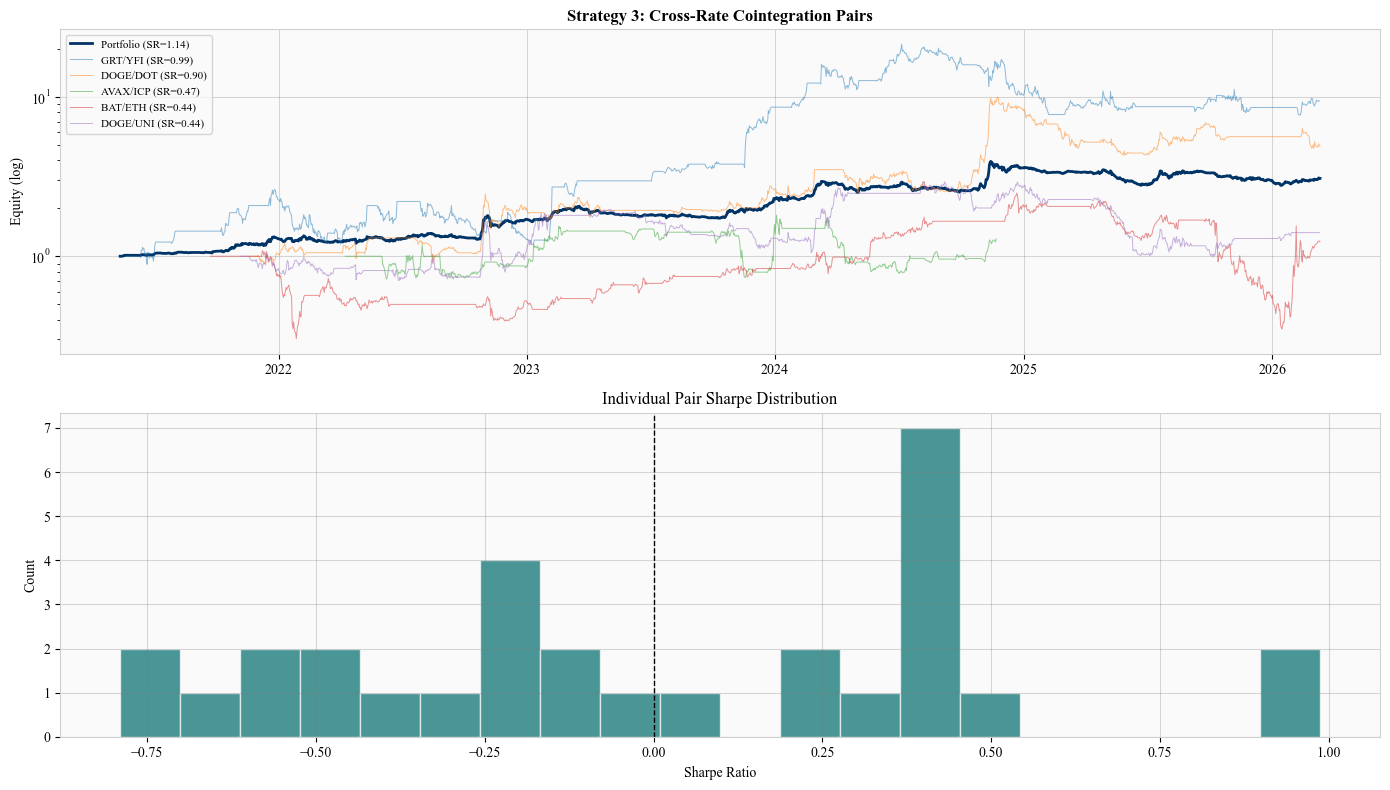


Pair Sharpe stats:  mean=-0.00  median=-0.06  >0: 14/30


In [19]:
if xr_pair_results:
    sorted_pairs = sorted(xr_pair_results, key=lambda x: x.get("sharpe", -99), reverse=True)
    best = sorted_pairs[0]

    fig, axes = plt.subplots(2, 1, figsize=(14, 8))

    if len(coint_port_eq) > 0:
        axes[0].plot(coint_port_eq.index, coint_port_eq.values,
                     color=NAVY, lw=2, label=f"Portfolio (SR={coint_port_m['sharpe']:.2f})")

    for r in sorted_pairs[:5]:
        if r["label"] in xr_pair_equities:
            eq = xr_pair_equities[r["label"]]
            axes[0].plot(eq.index, eq.values, lw=0.7, alpha=0.5,
                         label=f"{r['label']} (SR={r['sharpe']:.2f})")

    axes[0].set_yscale("log")
    axes[0].set_ylabel("Equity (log)")
    axes[0].set_title("Strategy 3: Cross-Rate Cointegration Pairs", fontweight="bold")
    axes[0].legend(fontsize=8)

    sharpes = [r["sharpe"] for r in xr_pair_results if not np.isnan(r["sharpe"])]
    axes[1].hist(sharpes, bins=20, color=TEAL, alpha=0.7, edgecolor="white")
    axes[1].axvline(0, color="black", lw=1, ls="--")
    axes[1].set_xlabel("Sharpe Ratio")
    axes[1].set_ylabel("Count")
    axes[1].set_title("Individual Pair Sharpe Distribution")

    fig.tight_layout()
    plt.show()

    print(f"\nPair Sharpe stats:  mean={np.mean(sharpes):.2f}  "
          f"median={np.median(sharpes):.2f}  >0: {sum(1 for s in sharpes if s > 0)}/{len(sharpes)}")

---
## 5 — Combined Comparison

In [20]:
all_metrics = []
all_equities = {}

if len(tri_port_eq) > 0:
    m = compute_metrics(tri_port_eq)
    m["label"] = "1: Tri-Basis Portfolio"
    all_metrics.append(m)
    all_equities["1: Tri-Basis"] = tri_port_eq

if len(ratio_eq) > 0:
    all_metrics.append(ratio_m)
    ratio_m_copy = ratio_m.copy()
    ratio_m_copy["label"] = f"2: BTC-Ratio MR (top {TOP_N})"
    all_metrics[-1] = ratio_m_copy
    all_equities["2: BTC-Ratio MR"] = ratio_eq

if len(coint_port_eq) > 0:
    m = compute_metrics(coint_port_eq)
    m["label"] = "3: XR Coint Portfolio"
    all_metrics.append(m)
    all_equities["3: XR Coint"] = coint_port_eq

btc_eq = usd_close["BTC-USD"].dropna()
btc_eq = btc_eq.loc[btc_eq.index >= START]
btc_eq = btc_eq / btc_eq.iloc[0]
m_btc = compute_metrics(btc_eq)
m_btc["label"] = "BTC Buy & Hold"
all_metrics.append(m_btc)
all_equities["BTC B&H"] = btc_eq

print(format_metrics_table(all_metrics))

Strategy                           CAGR      Vol   Sharpe  Sortino    MaxDD    Hit%    Skew    Kurt
---------------------------------------------------------------------------------------------------
1: Tri-Basis Portfolio          -17.3%    5.1%    -3.68    -3.94  -69.6%  24.5%   -1.64   32.69
2: BTC-Ratio MR (top 3)         -49.0%   34.8%    -1.76    -2.15  -98.6%  48.5%   -0.55    6.50
3: XR Coint Portfolio            26.2%   22.8%     1.14     1.80  -29.4%  47.8%    1.73   18.55
BTC Buy & Hold                   44.2%   62.0%     0.91     1.22  -76.7%  50.8%   -0.52   12.10


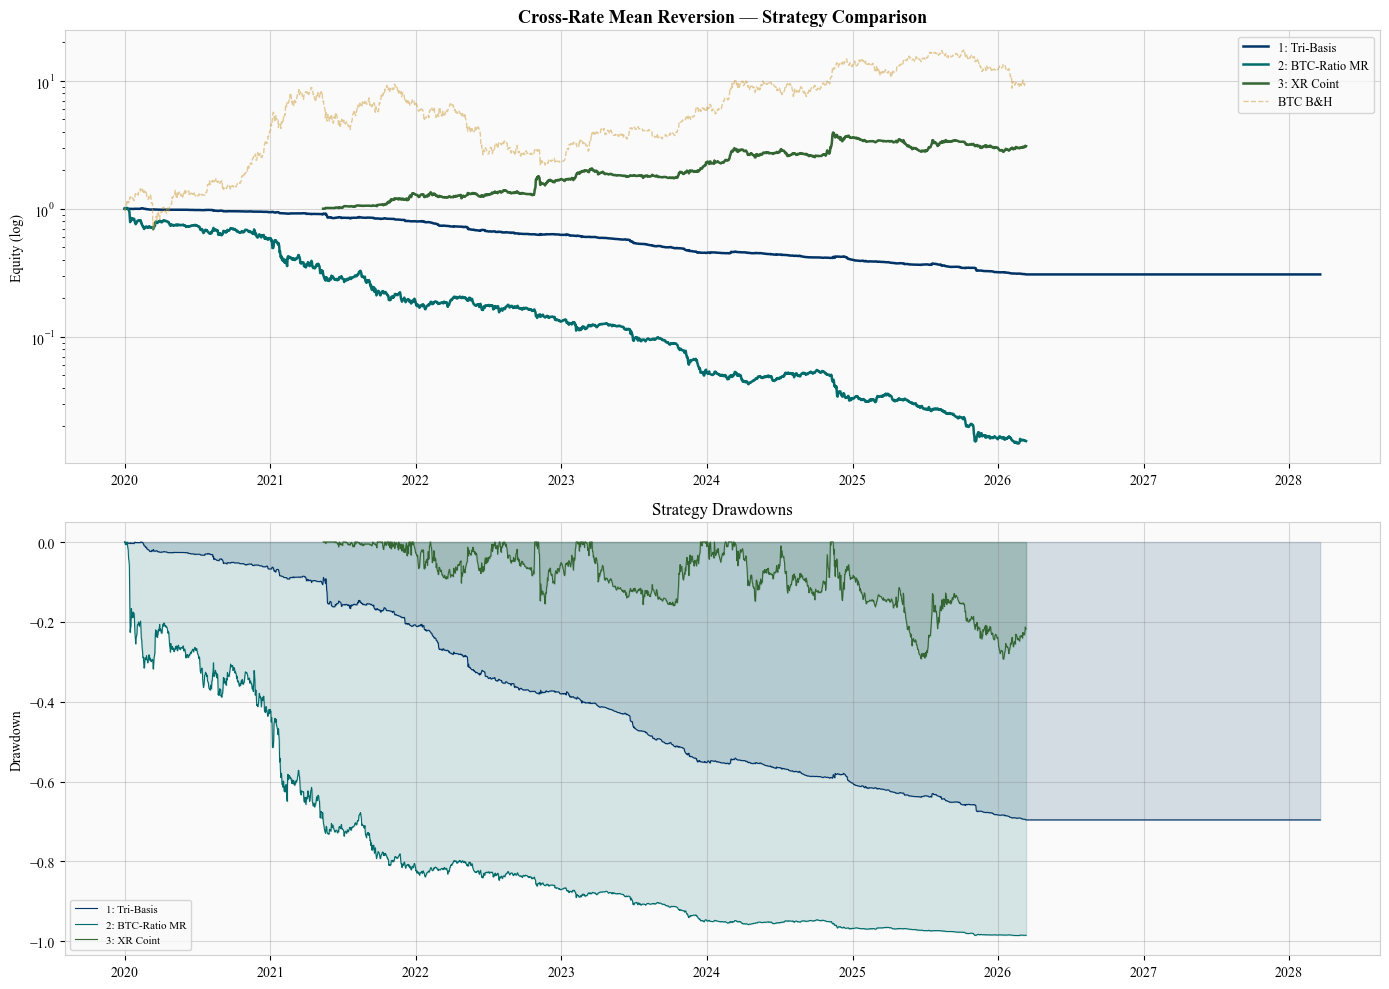

In [21]:
colors = [NAVY, TEAL, GREEN, GOLD, RED, GRAY]

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

for i, (label, eq) in enumerate(all_equities.items()):
    axes[0].plot(eq.index, eq.values, label=label,
                 color=colors[i % len(colors)], lw=1.8 if i < 3 else 1.0,
                 alpha=1.0 if i < 3 else 0.5,
                 ls="-" if i < 3 else "--")

axes[0].set_yscale("log")
axes[0].set_ylabel("Equity (log)")
axes[0].set_title("Cross-Rate Mean Reversion — Strategy Comparison", fontweight="bold", fontsize=13)
axes[0].legend(fontsize=9)

for i, (label, eq) in enumerate(all_equities.items()):
    if "B&H" in label:
        continue
    dd = eq / eq.cummax() - 1
    axes[1].fill_between(dd.index, 0, dd.values, alpha=0.15, color=colors[i % len(colors)])
    axes[1].plot(dd.index, dd.values, lw=0.8, color=colors[i % len(colors)], label=label)

axes[1].set_ylabel("Drawdown")
axes[1].set_title("Strategy Drawdowns")
axes[1].legend(fontsize=8, loc="lower left")

fig.tight_layout()
plt.show()

### Rolling Sharpe (252-day)

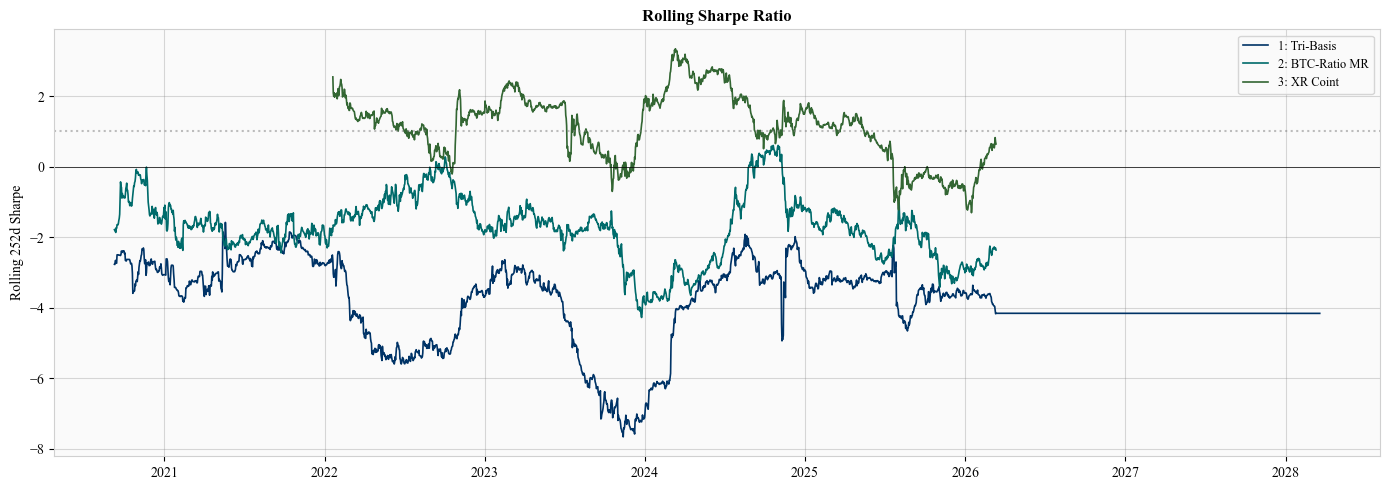

In [22]:
fig, ax = plt.subplots(figsize=(14, 5))

for i, (label, eq) in enumerate(all_equities.items()):
    if "B&H" in label:
        continue
    ret = eq.pct_change().dropna()
    rolling_sr = (ret.rolling(252).mean() / ret.rolling(252).std()) * np.sqrt(365)
    ax.plot(rolling_sr.index, rolling_sr.values, label=label,
            color=colors[i % len(colors)], lw=1.2)

ax.axhline(0, color="black", lw=0.5)
ax.axhline(1, color="gray", ls=":", alpha=0.5)
ax.set_ylabel("Rolling 252d Sharpe")
ax.set_title("Rolling Sharpe Ratio", fontweight="bold")
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

### Correlation between strategies

In [23]:
strat_rets = pd.DataFrame({
    k: v.pct_change() for k, v in all_equities.items()
}).dropna()

corr = strat_rets.corr()
print("Daily return correlations:")
print(corr.to_string(float_format="{:.3f}".format))

Daily return correlations:
                 1: Tri-Basis  2: BTC-Ratio MR  3: XR Coint  BTC B&H
1: Tri-Basis            1.000            0.027       -0.010    0.020
2: BTC-Ratio MR         0.027            1.000       -0.049    0.012
3: XR Coint            -0.010           -0.049        1.000    0.289
BTC B&H                 0.020            0.012        0.289    1.000


---
## 6 — Conclusions & Next Steps

**Key findings:**
- The triangular basis (actual vs implied cross rate) tests whether crypto market microstructure creates exploitable mispricings
- BTC-ratio mean reversion captures relative value dislocations among alts, hedged against BTC exposure
- Cross-rate cointegration pairs extend the Jansen stat-arb framework to a new asset universe

**Potential improvements:**
- Higher frequency (hourly/4h) for the triangular basis — arb opportunities likely close within hours
- Dynamic entry thresholds based on rolling vol regime
- Combine with momentum: only fade when momentum is turning
- Volume-weighted spread estimation
- Multi-leg: add USDC and USDT legs for richer triangular relationships

---
## 7 — 1-Minute Triangular Basis

The daily triangular basis was **stationary** (all 23 pairs passed ADF) but
Sharpe was deeply negative — the arb closes too fast for daily rebalancing.

Here we reload at 1-minute resolution and sweep lookback / cost parameters
to find the frequency at which this basis becomes tradeable.

In [24]:
TOP_XR = ["ETH-BTC", "LTC-BTC", "SOL-BTC", "BCH-BTC", "LINK-BTC", "ADA-BTC"]
MIN_START = "2023-01-01"
MIN_END   = "2026-03-13"

needed = []
for xr in TOP_XR:
    base = xr.split("-")[0]
    needed.extend([xr, f"{base}-USD"])
needed.append("BTC-USD")
needed = sorted(set(needed))

placeholders = ",".join(["?"] * len(needed))
con = duckdb.connect(DB_PATH, read_only=True)
raw = con.execute(f"""
    SELECT symbol, ts, close
    FROM candles_1m
    WHERE symbol IN ({placeholders})
      AND ts >= '{MIN_START}' AND ts <= '{MIN_END}'
      AND close > 0
    ORDER BY ts
""", needed).fetch_df()
con.close()

raw["ts"] = pd.to_datetime(raw["ts"], utc=True).dt.tz_localize(None)
print(f"Loaded {len(raw):,} rows for {raw['symbol'].nunique()} symbols")
print(f"Period: {raw['ts'].min()} → {raw['ts'].max()}")
print(f"\nRows per symbol:")
print(raw.groupby("symbol").size().sort_values(ascending=False).to_string())

Loaded 14,370,451 rows for 13 symbols
Period: 2023-01-01 08:00:00 → 2026-03-13 07:00:00

Rows per symbol:


symbol
BTC-USD     1679509
ETH-USD     1679477
LTC-USD     1678293
SOL-USD     1675987
ADA-USD     1647947
LINK-USD    1630872
BCH-USD     1534127
ETH-BTC      859934
SOL-BTC      555421
BCH-BTC      437578
LINK-BTC     418754
LTC-BTC      352531
ADA-BTC      220021


In [25]:
close_1m = raw.pivot_table(index="ts", columns="symbol", values="close", aggfunc="last")
close_1m = close_1m.ffill(limit=5)  # fill small gaps (up to 5 min)

print(f"Wide panel: {close_1m.shape[0]:,} timestamps × {close_1m.shape[1]} symbols")
print(f"\nNon-null coverage:")
coverage = close_1m.notna().mean().sort_values(ascending=False)
for sym, pct in coverage.items():
    print(f"  {sym:<12s} {pct:.1%}")
del raw

Wide panel: 1,679,543 timestamps × 13 symbols

Non-null coverage:
  BTC-USD      100.0%
  ETH-USD      100.0%
  LTC-USD      100.0%
  SOL-USD      100.0%
  LINK-USD     100.0%
  BCH-USD      100.0%
  ADA-USD      100.0%
  ETH-BTC      92.6%
  SOL-BTC      78.1%
  BCH-BTC      62.7%
  LTC-BTC      61.4%
  LINK-BTC     55.8%
  ADA-BTC      45.6%


### Basis statistics at 1-minute

In [26]:
btc_usd_1m = close_1m["BTC-USD"]

basis_1m = {}
for xr_sym in TOP_XR:
    base = xr_sym.split("-")[0]
    usd_sym = f"{base}-USD"
    if xr_sym not in close_1m.columns or usd_sym not in close_1m.columns:
        continue

    actual = close_1m[xr_sym]
    implied = close_1m[usd_sym] / btc_usd_1m
    mask = actual.notna() & implied.notna() & (actual > 0) & (implied > 0)

    b = np.log(actual[mask]) - np.log(implied[mask])
    basis_1m[base] = b

print(f"{'Pair':<10s} {'N obs':>12s} {'Mean(bps)':>10s} {'Std(bps)':>10s} "
      f"{'AC(1)':>8s} {'AC(60)':>8s} {'AC(1440)':>10s} {'ADF p':>8s}")
print("-" * 80)

for base, b in sorted(basis_1m.items(), key=lambda x: -len(x[1])):
    ac1 = b.autocorr(lag=1)
    ac60 = b.autocorr(lag=60)
    ac1440 = b.autocorr(lag=1440)
    # ADF on last 50K obs with maxlag=120 (2 hours) — keeps runtime reasonable
    adf_sample = b.dropna().values[-50_000:]
    adf_p = adfuller(adf_sample, maxlag=120, regression="c")[1]
    print(f"{base:<10s} {len(b):>12,} {b.mean()*1e4:>10.2f} {b.std()*1e4:>10.2f} "
          f"{ac1:>8.4f} {ac60:>8.4f} {ac1440:>10.4f} {adf_p:>8.4f}")

Pair              N obs  Mean(bps)   Std(bps)    AC(1)   AC(60)   AC(1440)    ADF p
--------------------------------------------------------------------------------


ETH           1,555,357       0.23       3.76   0.3861   0.0210     0.0066   0.0000


SOL           1,311,764      -0.01      10.29   0.5132   0.0057     0.0013   0.0000


BCH           1,052,576      -0.09      11.98   0.5873   0.0306     0.0103   0.0000


LTC           1,031,369       0.23      11.54   0.5958  -0.0039     0.0025   0.0000


LINK            936,510       0.14      13.98   0.6340   0.0032    -0.0025   0.0000


ADA             765,271       0.27      16.94   0.6537   0.0124    -0.0002   0.0000


### Multi-frequency backtest engine

The raw 1-min basis has AC(1) of 0.4–0.65: it's **persistent** at the minute scale
and only mean-reverts over hours. We need to find the right rebalancing frequency.

Strategy: resample to {5m, 15m, 1h, 4h} → compute z-score → trade with minimum hold.

In [27]:
from numba import njit

@njit
def _zscore_positions_hold(
    zscore: np.ndarray,
    entry_z: float,
    exit_z: float,
    stop_z: float,
    min_hold: int,
) -> np.ndarray:
    """State-machine with minimum holding period."""
    n = len(zscore)
    pos = np.zeros(n)
    state = 0
    bars_held = 0
    for i in range(n):
        z = zscore[i]
        if np.isnan(z):
            pos[i] = state
            if state != 0:
                bars_held += 1
            continue

        if state != 0:
            bars_held += 1

        if state == 0:
            if z < -entry_z:
                state = 1
                bars_held = 0
            elif z > entry_z:
                state = -1
                bars_held = 0
        elif bars_held >= min_hold:
            if state == 1:
                if z > -exit_z or z < -stop_z:
                    state = 0
                    bars_held = 0
            elif state == -1:
                if z < exit_z or z > stop_z:
                    state = 0
                    bars_held = 0
        pos[i] = state
    return pos


def resample_basis(basis_1m: pd.Series, freq: str) -> pd.Series:
    """Resample 1-min basis to a coarser frequency using last value."""
    return basis_1m.resample(freq).last().dropna()


def backtest_tri_freq(
    basis: pd.Series,
    close_base_usd: pd.Series,
    close_btc_usd: pd.Series,
    freq: str,
    lookback: int,
    entry_z: float = 2.0,
    exit_z: float = 0.5,
    stop_z: float = 6.0,
    min_hold: int = 1,
    cost_bps: float = 10.0,
) -> tuple[dict, pd.Series]:
    """Backtest tri-basis at a given rebalancing frequency."""
    b = resample_basis(basis, freq)
    base_c = close_base_usd.resample(freq).last().reindex(b.index).ffill()
    btc_c  = close_btc_usd.resample(freq).last().reindex(b.index).ffill()

    ret_base = base_c.pct_change().fillna(0)
    ret_btc  = btc_c.pct_change().fillna(0)

    ma = b.rolling(lookback, min_periods=max(lookback // 2, 2)).mean()
    sd = b.rolling(lookback, min_periods=max(lookback // 2, 2)).std()
    zscore = ((b - ma) / sd.clip(lower=1e-10)).values

    pos = _zscore_positions_hold(zscore, entry_z, exit_z, stop_z, min_hold)

    spread_ret = ret_base.values - ret_btc.values
    strat_ret = np.roll(pos, 1) * spread_ret
    strat_ret[0] = 0.0

    turnover = np.abs(np.diff(pos, prepend=0))
    cost = turnover * (cost_bps / 1e4) * 2
    net_ret = strat_ret - cost
    equity = np.cumprod(1 + net_ret)
    eq_series = pd.Series(equity, index=b.index)

    m = compute_metrics(eq_series)
    m["n_trades"] = int(turnover.sum() / 2)
    m["time_in_market"] = float(np.mean(np.abs(pos)))
    bars_per_trade = len(pos) * m["time_in_market"] / max(m["n_trades"], 1)
    m["avg_hold_bars"] = bars_per_trade
    return m, eq_series

# Warm up Numba JIT
_ = _zscore_positions_hold(np.array([0.0, 1.0, -3.0, 3.0, 0.0]), 2.0, 0.5, 6.0, 1)
print("Multi-frequency backtest engine ready (Numba-compiled).")

Multi-frequency backtest engine ready (Numba-compiled).


### Multi-frequency sweep — frequency × lookback × pair

Rebalance frequencies: 5m, 15m, 1h, 4h. Lookback in bars at each frequency.

In [28]:
FREQS = {
    "5min":  {"lookbacks": [24, 72, 144, 288], "label": "5m"},    # 2h, 6h, 12h, 1d in 5-min bars
    "15min": {"lookbacks": [24, 48, 96, 192], "label": "15m"},    # 6h, 12h, 1d, 2d
    "1h":    {"lookbacks": [12, 24, 48, 168], "label": "1h"},     # 12h, 1d, 2d, 1w
    "4h":    {"lookbacks": [6, 12, 42, 84], "label": "4h"},       # 1d, 2d, 1w, 2w
}
ENTRY_Z_HF = 2.0
EXIT_Z_HF = 0.5
STOP_Z_HF = 6.0
MIN_HOLD_BARS = 3  # minimum 3 bars at each frequency before exiting
COST_BPS_HF = 10.0

sweep_hf = []
for freq, cfg in FREQS.items():
    for base, b in basis_1m.items():
        usd_sym = f"{base}-USD"
        c_base = close_1m[usd_sym]
        c_btc  = close_1m["BTC-USD"]

        for lb in cfg["lookbacks"]:
            try:
                m, _ = backtest_tri_freq(
                    b, c_base, c_btc,
                    freq=freq, lookback=lb,
                    entry_z=ENTRY_Z_HF, exit_z=EXIT_Z_HF,
                    stop_z=STOP_Z_HF, min_hold=MIN_HOLD_BARS,
                    cost_bps=COST_BPS_HF,
                )
                m["base"] = base
                m["freq"] = cfg["label"]
                m["lookback"] = lb
                sweep_hf.append(m)
            except Exception as e:
                print(f"  {base} {freq} lb={lb}: {e}")

sweep_hf_df = pd.DataFrame(sweep_hf)
print(f"Sweep complete: {len(sweep_hf_df)} runs across {len(FREQS)} frequencies")

Sweep complete: 96 runs across 4 frequencies


In [29]:
print("=== Mean Sharpe across all pairs — by frequency × lookback ===\n")
for freq_label in ["5m", "15m", "1h", "4h"]:
    sub = sweep_hf_df[sweep_hf_df["freq"] == freq_label]
    if sub.empty:
        continue
    piv = sub.pivot_table(index="base", columns="lookback", values="sharpe")
    print(f"--- Rebalance every {freq_label} (10 bps/leg, min_hold={MIN_HOLD_BARS} bars) ---")
    print(piv.to_string(float_format="{:.2f}".format))
    avg = piv.mean()
    print(f"  Mean: {avg.to_dict()}")
    print()

print("\n=== Best config per pair ===\n")
best_per_pair = sweep_hf_df.loc[sweep_hf_df.groupby("base")["sharpe"].idxmax()]
for _, row in best_per_pair.sort_values("sharpe", ascending=False).iterrows():
    print(f"  {row['base']:<8s} freq={row['freq']:<4s} lb={int(row['lookback']):>3d}  "
          f"SR={row['sharpe']:>6.2f}  CAGR={row['cagr']:>7.1%}  "
          f"MaxDD={row['max_dd']:>7.1%}  Trades={int(row['n_trades']):>5d}  "
          f"AvgHold={row['avg_hold_bars']:.0f} bars")

=== Mean Sharpe across all pairs — by frequency × lookback ===

--- Rebalance every 5m (10 bps/leg, min_hold=3 bars) ---
lookback   24    72    144   288
base                            
ADA      -3.23 -3.15 -3.06 -3.01
BCH      -3.55 -3.40 -3.26 -3.22
ETH      -4.79 -4.72 -4.68 -4.57
LINK     -3.53 -3.25 -3.17 -3.10
LTC      -3.56 -3.43 -3.28 -3.25
SOL      -3.68 -3.57 -3.54 -3.44
  Mean: {24: -3.7207699670965115, 72: -3.5862708320743617, 144: -3.498528537650744, 288: -3.4324072072133163}

--- Rebalance every 15m (10 bps/leg, min_hold=3 bars) ---
lookback   24    48    96    192
base                            
ADA      -2.34 -2.23 -2.30 -2.20
BCH      -2.69 -2.57 -2.59 -2.52
ETH      -3.78 -3.78 -3.76 -3.65
LINK     -2.60 -2.54 -2.40 -2.36
LTC      -2.79 -2.73 -2.68 -2.61
SOL      -2.68 -2.74 -2.68 -2.68
  Mean: {24: -2.8129460246762554, 48: -2.7657373403344714, 96: -2.7340006740774836, 192: -2.6693791652964958}

--- Rebalance every 1h (10 bps/leg, min_hold=3 bars) ---
lookback   12 

### Best frequency — equity curves and portfolio

In [30]:
# Pick best freq+lookback per pair; run each with its own optimal setting
best_per = sweep_hf_df.loc[sweep_hf_df.groupby("base")["sharpe"].idxmax()]

# Also pick a single "best global" config (best median Sharpe across pairs)
global_sr = sweep_hf_df.groupby(["freq", "lookback"])["sharpe"].median()
best_global_idx = global_sr.idxmax()
best_freq, best_lb = best_global_idx
print(f"Best global config: freq={best_freq}, lookback={best_lb} "
      f"(median SR={global_sr.loc[best_global_idx]:.2f})\n")

pair_equities_hf = {}
pair_metrics_hf = []

freq_map = {"5m": "5min", "15m": "15min", "1h": "1h", "4h": "4h"}

for base, b in basis_1m.items():
    usd_sym = f"{base}-USD"
    c_base = close_1m[usd_sym]
    c_btc  = close_1m["BTC-USD"]

    m, eq = backtest_tri_freq(
        b, c_base, c_btc,
        freq=freq_map[best_freq], lookback=best_lb,
        entry_z=ENTRY_Z_HF, exit_z=EXIT_Z_HF, stop_z=STOP_Z_HF,
        min_hold=MIN_HOLD_BARS, cost_bps=COST_BPS_HF,
    )
    m["label"] = base
    pair_equities_hf[base] = eq
    pair_metrics_hf.append(m)
    print(f"  {base:<8s} SR={m['sharpe']:>6.2f}  CAGR={m['cagr']:>8.1%}  "
          f"MaxDD={m['max_dd']:>7.1%}  Trades={m['n_trades']:>5,}  "
          f"AvgHold={m['avg_hold_bars']:.0f} bars  TiM={m['time_in_market']:.0%}")

Best global config: freq=4h, lookback=6 (median SR=-0.08)

  ETH      SR= -0.50  CAGR=   -0.6%  MaxDD= -10.3%  Trades=   12  AvgHold=3 bars  TiM=1%
  LTC      SR= -0.22  CAGR=   -0.5%  MaxDD= -10.0%  Trades=   17  AvgHold=3 bars  TiM=1%
  SOL      SR=  0.11  CAGR=    0.3%  MaxDD=  -6.6%  Trades=   18  AvgHold=3 bars  TiM=1%
  BCH      SR=  0.11  CAGR=    0.3%  MaxDD=  -9.0%  Trades=   18  AvgHold=3 bars  TiM=1%


  LINK     SR=  0.05  CAGR=    0.1%  MaxDD=  -8.0%  Trades=   20  AvgHold=3 bars  TiM=1%


  ADA      SR= -0.33  CAGR=   -1.0%  MaxDD= -18.1%  Trades=    6  AvgHold=3 bars  TiM=0%


In [31]:
# Equal-weight portfolio of all pairs
port_rets_hf = pd.DataFrame({
    k: v.pct_change().fillna(0) for k, v in pair_equities_hf.items()
})
port_ret_hf = port_rets_hf.mean(axis=1)
port_eq_hf = (1 + port_ret_hf).cumprod()
port_m_hf = compute_metrics(port_eq_hf)
port_m_hf["label"] = f"Tri-Basis Portfolio ({best_freq}, lb={best_lb})"

# BTC benchmark at same frequency
btc_hf = close_1m["BTC-USD"].resample(freq_map[best_freq]).last().reindex(port_eq_hf.index).ffill()
btc_hf = btc_hf / btc_hf.iloc[0]
btc_m_hf = compute_metrics(btc_hf)
btc_m_hf["label"] = "BTC Buy & Hold"

print(format_metrics_table(pair_metrics_hf + [port_m_hf, btc_m_hf]))

Strategy                           CAGR      Vol   Sharpe  Sortino    MaxDD    Hit%    Skew    Kurt
---------------------------------------------------------------------------------------------------
ETH                              -0.6%    1.1%    -0.50    -0.06  -10.3%   0.2%  -17.50  769.40
LTC                              -0.5%    2.2%    -0.22    -0.03  -10.0%   0.4%  -12.03  590.68
SOL                               0.3%    2.6%     0.11     0.02   -6.6%   0.5%   15.09  699.73
BCH                               0.3%    3.0%     0.11     0.03   -9.0%   0.4%   42.56 2876.92
LINK                              0.1%    3.3%     0.05     0.01   -8.0%   0.5%   10.99 1300.79
ADA                              -1.0%    2.8%    -0.33    -0.02  -18.1%   0.1%  -33.57 1902.06
Tri-Basis Portfolio (4h, lb=6)   -0.2%    1.0%    -0.19    -0.06   -4.1%   2.0%    3.78  348.39
BTC Buy & Hold                    7.9%   19.1%     0.49     0.65  -50.0%  51.6%    0.10    7.48


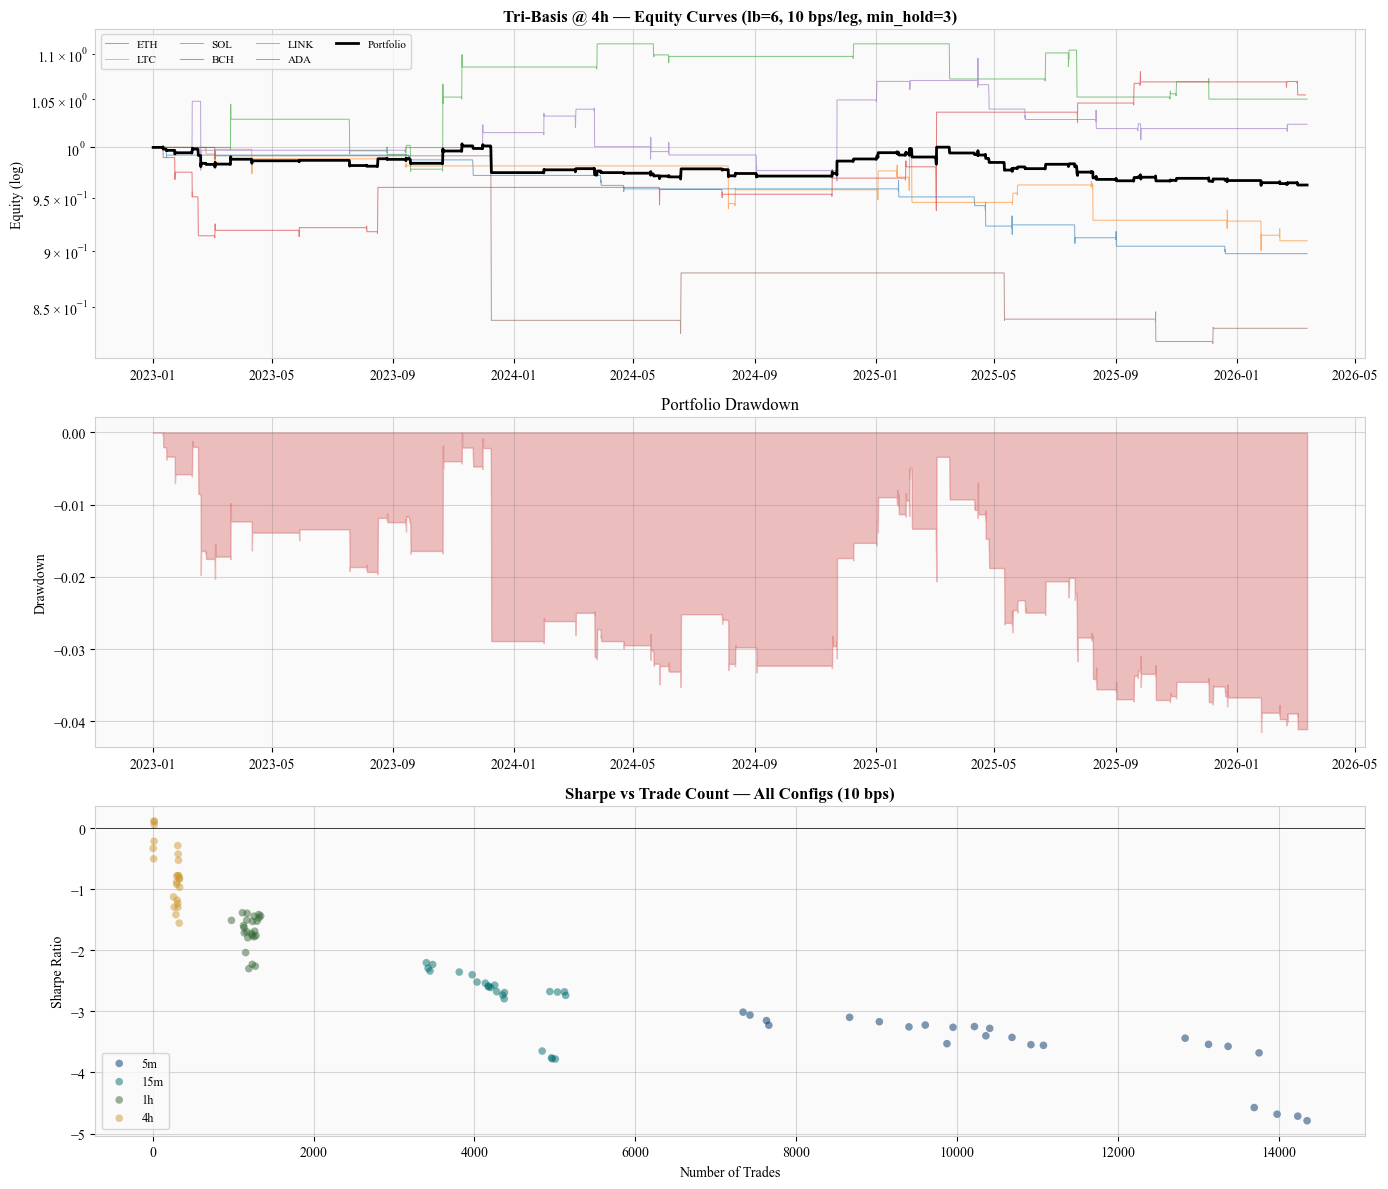

In [32]:
def resample_eq(eq, freq="1h"):
    return eq.resample(freq).last().dropna()

fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# Equity curves
ax = axes[0]
for i, (base, eq) in enumerate(pair_equities_hf.items()):
    eq_h = resample_eq(eq)
    ax.plot(eq_h.index, eq_h.values, lw=0.7, alpha=0.6, label=base)
port_h = resample_eq(port_eq_hf)
ax.plot(port_h.index, port_h.values, color="black", lw=2.0, label="Portfolio")
ax.set_yscale("log")
ax.set_ylabel("Equity (log)")
ax.set_title(
    f"Tri-Basis @ {best_freq} — Equity Curves (lb={best_lb}, 10 bps/leg, min_hold={MIN_HOLD_BARS})",
    fontweight="bold", fontsize=12,
)
ax.legend(fontsize=8, ncol=4)

# Drawdown
ax = axes[1]
dd = port_eq_hf / port_eq_hf.cummax() - 1
dd_h = resample_eq(dd)
ax.fill_between(dd_h.index, 0, dd_h.values, color=RED, alpha=0.3)
ax.set_ylabel("Drawdown")
ax.set_title("Portfolio Drawdown")

# All sweep results as scatter: x=n_trades, y=sharpe, color=freq
ax = axes[2]
freq_colors = {"5m": NAVY, "15m": TEAL, "1h": GREEN, "4h": GOLD}
for freq_label, color in freq_colors.items():
    sub = sweep_hf_df[sweep_hf_df["freq"] == freq_label]
    ax.scatter(sub["n_trades"], sub["sharpe"], c=color, alpha=0.5,
               s=30, label=freq_label, edgecolors="none")
ax.axhline(0, color="black", lw=0.5)
ax.set_xlabel("Number of Trades")
ax.set_ylabel("Sharpe Ratio")
ax.set_title("Sharpe vs Trade Count — All Configs (10 bps)", fontweight="bold")
ax.legend(fontsize=9)

fig.tight_layout()
plt.show()

### Best single pair — deep dive

Best pair: SOL-BTC  (Sharpe=0.11, freq=4h)



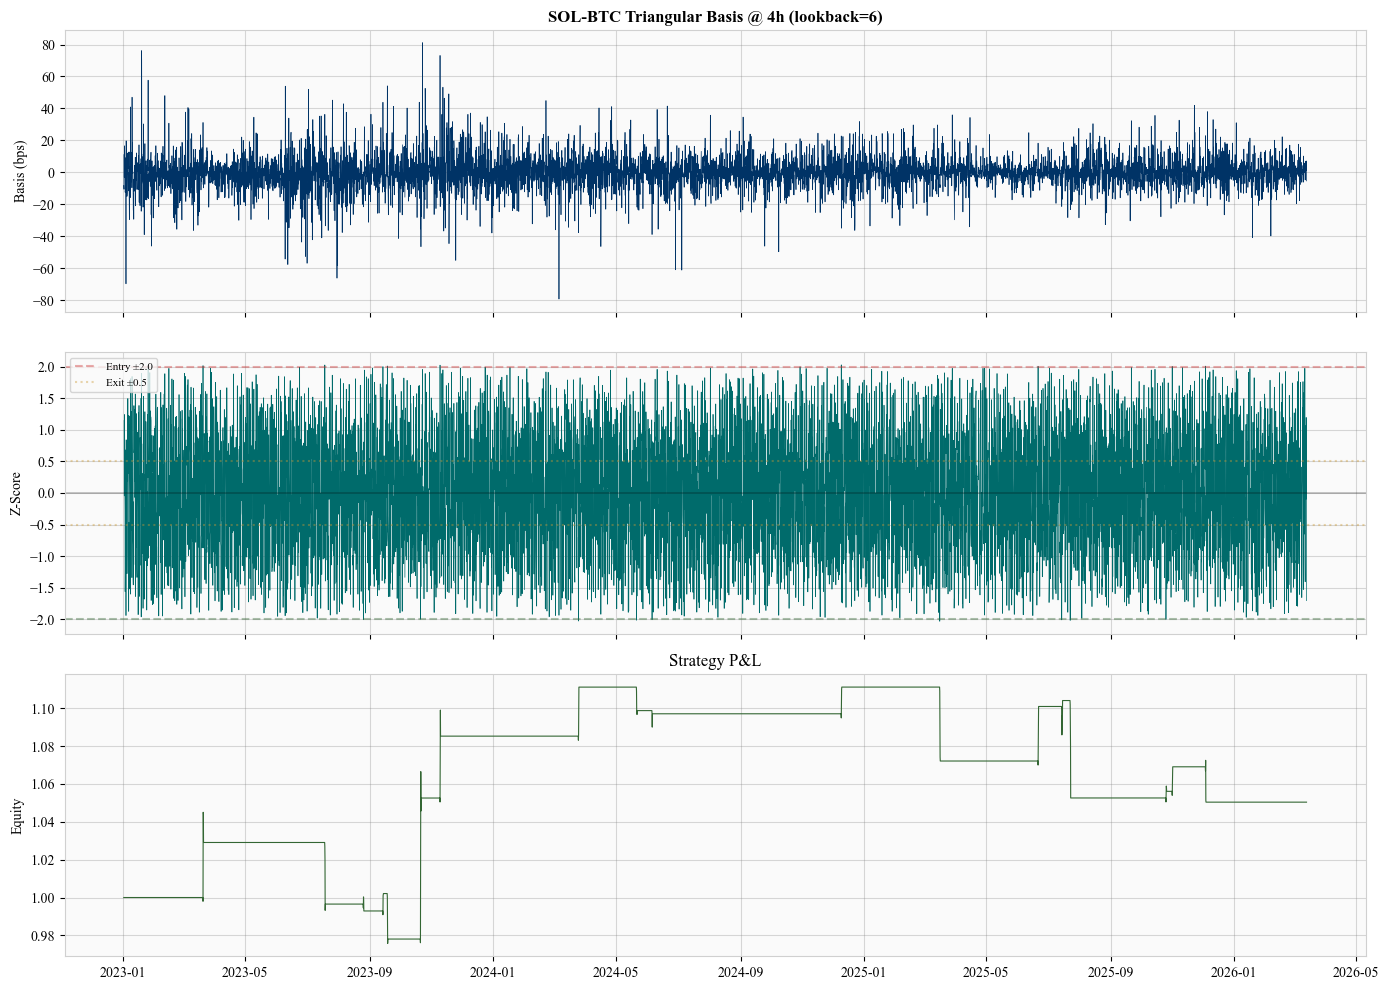

In [33]:
best_pair_hf = max(pair_metrics_hf, key=lambda x: x.get("sharpe", -99))
bp = best_pair_hf["label"]
print(f"Best pair: {bp}-BTC  (Sharpe={best_pair_hf['sharpe']:.2f}, freq={best_freq})\n")

b = basis_1m[bp]
b_rs = resample_basis(b, freq_map[best_freq])
ma = b_rs.rolling(best_lb, min_periods=max(best_lb // 2, 2)).mean()
sd = b_rs.rolling(best_lb, min_periods=max(best_lb // 2, 2)).std()
zs = (b_rs - ma) / sd.clip(lower=1e-10)

# Resample for plots
plot_freq = "1h" if best_freq in ["5m", "15m"] else "4h"
b_plot = b_rs.resample(plot_freq).last().dropna()
zs_plot = zs.resample(plot_freq).last().dropna()
eq_plot = resample_eq(pair_equities_hf[bp], plot_freq)

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(b_plot.index, b_plot.values * 1e4, color=NAVY, lw=0.5)
axes[0].set_ylabel("Basis (bps)")
axes[0].set_title(
    f"{bp}-BTC Triangular Basis @ {best_freq} (lookback={best_lb})",
    fontweight="bold", fontsize=12,
)

axes[1].plot(zs_plot.index, zs_plot.values, color=TEAL, lw=0.5)
axes[1].axhline(ENTRY_Z_HF, color=RED, ls="--", alpha=0.4, label=f"Entry ±{ENTRY_Z_HF}")
axes[1].axhline(-ENTRY_Z_HF, color=GREEN, ls="--", alpha=0.4)
axes[1].axhline(EXIT_Z_HF, color=GOLD, ls=":", alpha=0.4, label=f"Exit ±{EXIT_Z_HF}")
axes[1].axhline(-EXIT_Z_HF, color=GOLD, ls=":", alpha=0.4)
axes[1].axhline(0, color="black", lw=0.3)
axes[1].set_ylabel("Z-Score")
axes[1].legend(fontsize=8)

axes[2].plot(eq_plot.index, eq_plot.values, color=GREEN, lw=0.8)
axes[2].set_ylabel("Equity")
axes[2].set_title("Strategy P&L")

fig.tight_layout()
plt.show()

### Cost sensitivity — at what cost level does the strategy break?

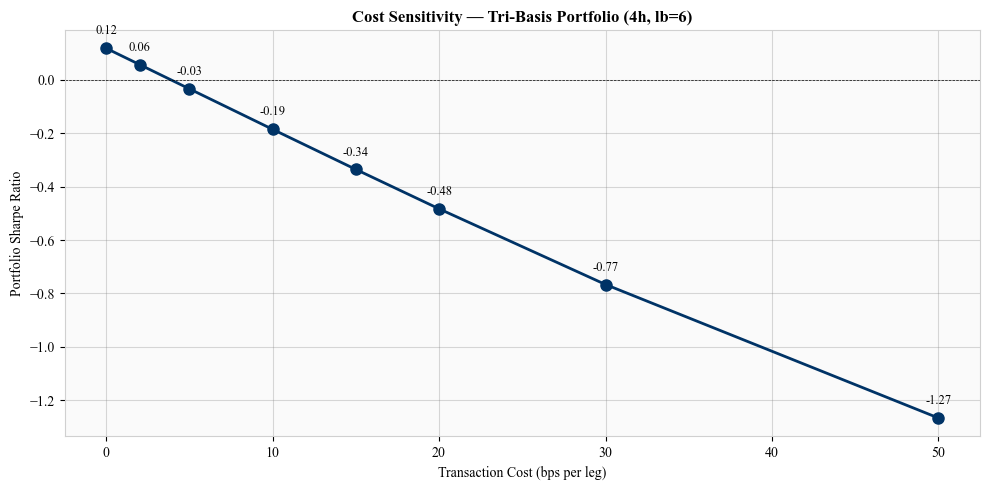

 cost_bps  sharpe  cagr  max_dd  vol
        0    0.12  0.00   -0.03 0.01
        2    0.06  0.00   -0.03 0.01
        5   -0.03 -0.00   -0.03 0.01
       10   -0.19 -0.00   -0.04 0.01
       15   -0.34 -0.00   -0.07 0.01
       20   -0.48 -0.01   -0.09 0.01
       30   -0.77 -0.01   -0.15 0.01
       50   -1.27 -0.01   -0.25 0.01


In [34]:
cost_sweep = [0, 2, 5, 10, 15, 20, 30, 50]
cost_results_hf = []

for cost in cost_sweep:
    port_rets_c = {}
    for base, b in basis_1m.items():
        usd_sym = f"{base}-USD"
        c_base = close_1m[usd_sym]
        c_btc  = close_1m["BTC-USD"]
        m, eq = backtest_tri_freq(
            b, c_base, c_btc,
            freq=freq_map[best_freq], lookback=best_lb,
            entry_z=ENTRY_Z_HF, exit_z=EXIT_Z_HF, stop_z=STOP_Z_HF,
            min_hold=MIN_HOLD_BARS, cost_bps=cost,
        )
        port_rets_c[base] = eq.pct_change().fillna(0)

    pr = pd.DataFrame(port_rets_c).mean(axis=1)
    peq = (1 + pr).cumprod()
    pm = compute_metrics(peq)
    pm["cost_bps"] = cost
    cost_results_hf.append(pm)

cost_hf_df = pd.DataFrame(cost_results_hf)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(cost_hf_df["cost_bps"], cost_hf_df["sharpe"], "o-", color=NAVY, lw=2, markersize=8)
ax.axhline(0, color="black", ls="--", lw=0.5)
ax.set_xlabel("Transaction Cost (bps per leg)")
ax.set_ylabel("Portfolio Sharpe Ratio")
ax.set_title(f"Cost Sensitivity — Tri-Basis Portfolio ({best_freq}, lb={best_lb})",
             fontweight="bold")
for _, row in cost_hf_df.iterrows():
    ax.annotate(f"{row['sharpe']:.2f}", (row["cost_bps"], row["sharpe"]),
                textcoords="offset points", xytext=(0, 10), fontsize=9, ha="center")
fig.tight_layout()
plt.show()

print(cost_hf_df[["cost_bps", "sharpe", "cagr", "max_dd", "vol"]].to_string(
    index=False,
    float_format=lambda x: f"{x:.2f}" if abs(x) < 10 else f"{x:.1%}",
))

### Yearly Sharpe stability

In [35]:
# Yearly breakdown for portfolio at 10 bps
port_ret_daily_hf = port_ret_hf.resample("1D").sum()
years = sorted(port_ret_daily_hf.index.year.unique())

print(f"{'Year':>6s} {'Sharpe':>8s} {'Return':>8s} {'Vol':>8s} {'MaxDD':>8s} {'HitRate':>8s}")
print("-" * 50)
for yr in years:
    yr_ret = port_ret_daily_hf[port_ret_daily_hf.index.year == yr]
    if len(yr_ret) < 30:
        continue
    yr_eq = (1 + yr_ret).cumprod()
    ym = compute_metrics(yr_eq)
    print(f"{yr:>6d} {ym['sharpe']:>8.2f} {ym['total_return']:>7.1%} "
          f"{ym['vol']:>7.1%} {ym['max_dd']:>7.1%} {ym['hit_rate']:>7.1%}")

  Year   Sharpe   Return      Vol    MaxDD  HitRate
--------------------------------------------------
  2023    -0.78   -2.5%    3.2%   -2.7%    3.6%
  2024     0.77    1.4%    1.8%   -0.8%    3.3%
  2025    -0.90   -2.3%    2.5%   -3.4%    5.2%
  2026    -3.13   -0.5%    0.7%   -0.5%    2.8%
